<div align="center">
    <font color="white" size="7">
        Deep Learning <br>
    </font>
    <font color="green" size="5">
        CE Department <br>
        Fall 1404 - Prof. Abdoos <br>
    </font>
    <font color="purple" size="5">
        HW3 Implementation <br>
    </font>
</div>


Fullname: Sobhan Mahmoudi

Student ID: 404443158

[I used codes in this page as help.](https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html)

# Imports & Configs

In [1]:
import torch
import random
import numpy as np
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torchvision import transforms, datasets
from sklearn.neighbors import NearestNeighbors
from torch.utils.data import random_split, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
torch.manual_seed(42)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# Device
set device to work with (GPU or CPU)

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Data, Transforms, Dataset & Dataloader

**Note**: The chosen dataset for this homework is **CIFAR-10**.

In [4]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [5]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

viz_dataset = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

train_and_val_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transform
)

train_size = int(0.9 * len(train_and_val_data))
val_size = len(train_and_val_data) - train_size

training_dataset, validation_dataset = random_split(
    train_and_val_data,
    [train_size, val_size]
)

test_dataset = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=test_transform
)

batch_size = 64

train_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(validation_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [Batch Size, Channels, Height, Width]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


Shape of X [Batch Size, Channels, Height, Width]: torch.Size([64, 3, 32, 32])
Shape of y: torch.Size([64]) torch.int64


# Visualization

Visualize 5 random images from each class in different columns


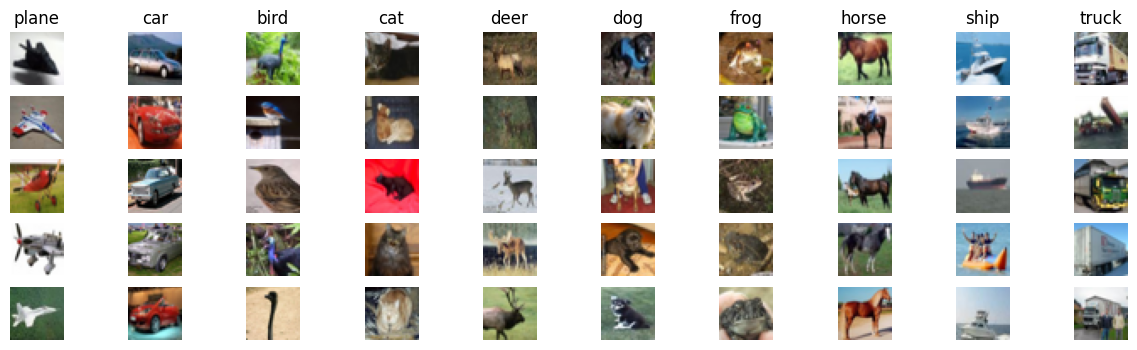

In [6]:
class_images = {i: [] for i in range(10)}

for X, y in viz_dataset:
    count_label_sampling_ended = 0

    if len(class_images[y]) < 5:
        class_images[y].append(X)

    for label in class_images:
        if len(class_images[label]) == 5:
            count_label_sampling_ended += 1

    if count_label_sampling_ended == len(classes):
        break

plt.figure(figsize=(15, 4))
for class_label in range(10):
    for image in range(5):
        img = class_images[class_label][image]
        plt.subplot(5, 10, image * 10 + class_label + 1)
        plt.imshow(img.permute(1, 2, 0))
        if image == 0:
            plt.title(classes[class_label])
        plt.axis("off")

plt.show()

# Model Architectures

## Model_1 (baseline)

Define a simple CNN without batch normalization and skip connections (just convolutional and fully connected layers).


**NOTICE:** The model that you will have defined outputs a vector containing 10 numbers (one for each class). Define a "feature map" that is a vector of size *N* (where *N > 10*) right before the last layer (You can then have a last layer like `nn.Linear(N, 10)`). We will use this later (we want to access the feature map of a sample when the sample is given to the model). The model tries to learn a representation of the samples in this feature space and we will see how good it could do this in later sections.

**Note**: Use `ReLU` activation function after conv filters.

**Hint:** You might want to design your forward function to return both the features and the final classification, or provide a separate method (e.g., forward_features) to extract them easily later.

In [7]:
class Model_1(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.flatten = nn.Flatten()

        self.block4 = nn.Sequential(
          nn.Linear(256 * 4 * 4, 256),
          nn.ReLU(),
        )

        self.output = nn.Linear(256, 10)

    def forward_features(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.block4(x)
        return x

    def forward(self, x):
        features = self.forward_features(x)
        output = self.output(features)
        return output

## Model_2 (BatchNorm)

Change architecture of the model_1 and add batch normalization to each convolutional layers.

**Hint**: Apply batch normalization after convolutional filters, and apply activation function afterwards.

In [ ]:
class Model_2(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.flatten = nn.Flatten()

        self.block4 = nn.Sequential(
          nn.Linear(256 * 4 * 4, 256),
          nn.ReLU(),
        )

        self.output = nn.Linear(256, 10)

    def forward_features(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.block4(x)
        return x

    def forward(self, x):
        features = self.forward_features(x)
        output = self.output(features)
        return output

## Model_3 (Skip connections)

Change model_1 and add skip connections (similar to a ResNet).

**Note:** You shouldn't change basic structure of model like the number of conv layers. just add skip connections to the same model_2.  

**Note:** If the dimensions (width/height or channels) change between blocks, you will need to implement a 1x1 convolution on the skip connection so the shapes match for addition.

In [ ]:
class Model_3(nn.Module):
    def __init__(self):
        super().__init__()

        self.skip1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=1, stride=1, bias=False),
        )
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
        )


        self.skip2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=1, stride=2, bias=False),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
        )


        self.skip3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=1, stride=2, bias=False),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False),
        )

        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()

        self.block4 = nn.Sequential(
          nn.Linear(256 * 8 * 8, 256),
          nn.ReLU(),
        )

        self.output = nn.Linear(256, 10)

    def forward_features(self, x):
        x = self.relu(self.block1(x) + self.skip1(x))
        x = self.relu(self.block2(x) + self.skip2(x))
        x = self.relu(self.block3(x) + self.skip3(x))
        x = self.flatten(x)
        return self.block4(x)

    def forward(self, x):
        return self.output(self.forward_features(x))

## Model_4 (BatchNorm + Skip connections)

Change model_1 and add both batch normalization to each layer as well as skip connections.

In [ ]:
class Model_4(nn.Module):
    def __init__(self):
        super().__init__()

        self.skip1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(64),
        )
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
        )


        self.skip2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=1, stride=2, bias=False),
            nn.BatchNorm2d(128),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
        )


        self.skip3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=1, stride=2, bias=False),
            nn.BatchNorm2d(256),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),
        )

        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()

        self.block4 = nn.Sequential(
          nn.Linear(256 * 8 * 8, 256),
          nn.ReLU(),
        )

        self.output = nn.Linear(256, 10)


    def forward_features(self, x):
        x = self.relu(self.block1(x) + self.skip1(x))
        x = self.relu(self.block2(x) + self.skip2(x))
        x = self.relu(self.block3(x) + self.skip3(x))
        x = self.flatten(x)
        return self.block4(x)

    def forward(self, x):
        return self.output(self.forward_features(x))

# Training

## Model instantiation

Create an instance of your model and move it to `device`

**Note:** Remember, you need to instantiate 3 models.

In [ ]:
model_1 = Model_1().to(device)
model_2 = Model_2().to(device)
model_3 = Model_3().to(device)
model_4 = Model_4().to(device)

## Criterion & Optimization

Define `criterion` and `optimizer` (Or `scheduler`)

In [8]:
loss_fn = nn.CrossEntropyLoss()

In [ ]:
model_1_SGD_optimizer = torch.optim.SGD(model_1.parameters(), lr=0.01, momentum=0.9)
model_2_SGD_optimizer = torch.optim.SGD(model_2.parameters(), lr=0.01, momentum=0.9)
model_3_SGD_optimizer = torch.optim.SGD(model_3.parameters(), lr=0.01, momentum=0.9)
model_4_SGD_optimizer = torch.optim.SGD(model_4.parameters(), lr=0.01, momentum=0.9)

In [9]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_val_acc = 0.0
        self.counter = 0
        self.should_stop = False

    def step(self, val_acc):
        if val_acc > self.best_val_acc + self.min_delta:
            self.best_val_acc = val_acc
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

## Train loop

Train your model

Tasks:
- [ ] What you need to print at each epoch:
  - Number of epochs
  - Train loss
  - Train accuracy
  - Validation loss
  - Validation accuracy
  <br>
- [ ] save train/validation loss and accuracy (of each epoch) in an array for later usage
<br>
<br>
- save or update the model with the highest validation accuracy after each epoch.

**Note**: Use SGD optimizer with no `weight_decay`.

In [10]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        correct += (pred.argmax(1) == y).sum().item()
        total += y.size(0)

    train_loss /= len(dataloader)
    train_acc = correct / total
    return train_loss, train_acc

In [11]:
def validation_one_epoch(dataloader, model, loss_fn):
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            pred = model(X)
            loss = loss_fn(pred, y)

            val_loss += loss.item()
            correct += (pred.argmax(1) == y).sum().item()
            total += y.size(0)

    val_loss /= len(dataloader)
    val_acc = correct / total
    return val_loss, val_acc

In [12]:
def train(train_dataloader, val_dataloader, model, loss_fn, optimizer, epochs, patience=5, model_name="model"):
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    early_stopping = EarlyStopping(patience=patience)

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(train_dataloader, model, loss_fn, optimizer)
        val_loss, val_acc = validation_one_epoch(val_dataloader, model, loss_fn)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_acc > early_stopping.best_val_acc:
            torch.save(model.state_dict(), f"best_{model_name}.pth")

        early_stopping.step(val_acc)

        if early_stopping.should_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc*100:.2f}%\n")

    return [train_losses, train_accs, val_losses, val_accs]

## Training the models

Now that you have the training loop in place, you can start training each model with SGD optimizer. Since you are going to compare the models, you should use the same number of epochs, same augmentations (if any are used), same batch size, and the same random seed to achieve a fair comparison.

Using SGD optimizer with a learning rate of 0.1, a momentum of 0.9, and no `weight_decay` is a good training configuration. You could also use your own configuration by training model_1 with different configurations, choosing the best found and using it to train the other 3 models to be consistent.

**Hint**: Use a different cell to train each model so you don't retrain the others unnecessarily.

In [13]:
epochs = 25

In [ ]:
result_1 = train(train_dataloader, val_dataloader, model_1, loss_fn, model_1_SGD_optimizer, epochs, 5, 'model_1')

Epoch [1/25]
Train Loss: 2.0455, Train Acc: 23.18%
Val   Loss: 1.7834, Val   Acc: 33.82%

Epoch [2/25]
Train Loss: 1.5124, Train Acc: 44.23%
Val   Loss: 1.3850, Val   Acc: 51.32%

Epoch [3/25]
Train Loss: 1.2006, Train Acc: 56.50%
Val   Loss: 1.0394, Val   Acc: 62.24%

Epoch [4/25]
Train Loss: 0.9724, Train Acc: 65.16%
Val   Loss: 0.9598, Val   Acc: 66.06%

Epoch [5/25]
Train Loss: 0.8253, Train Acc: 71.03%
Val   Loss: 0.8694, Val   Acc: 70.86%

Epoch [6/25]
Train Loss: 0.7308, Train Acc: 74.48%
Val   Loss: 0.7973, Val   Acc: 73.04%

Epoch [7/25]
Train Loss: 0.6466, Train Acc: 77.48%
Val   Loss: 0.6078, Val   Acc: 78.64%

Epoch [8/25]
Train Loss: 0.5861, Train Acc: 79.61%
Val   Loss: 0.6127, Val   Acc: 78.18%

Epoch [9/25]
Train Loss: 0.5340, Train Acc: 81.36%
Val   Loss: 0.6313, Val   Acc: 78.04%

Epoch [10/25]
Train Loss: 0.5013, Train Acc: 82.75%
Val   Loss: 0.5283, Val   Acc: 81.08%

Epoch [11/25]
Train Loss: 0.4686, Train Acc: 83.70%
Val   Loss: 0.5135, Val   Acc: 82.56%

Epoch [1

In [ ]:
result_2 = train(train_dataloader, val_dataloader, model_2, loss_fn, model_2_SGD_optimizer, epochs, 5, 'model_2')

Epoch [1/25]
Train Loss: 1.4075, Train Acc: 48.76%
Val   Loss: 1.1371, Val   Acc: 59.22%

Epoch [2/25]
Train Loss: 0.9666, Train Acc: 65.91%
Val   Loss: 0.8608, Val   Acc: 69.52%

Epoch [3/25]
Train Loss: 0.8014, Train Acc: 72.13%
Val   Loss: 0.8351, Val   Acc: 71.14%

Epoch [4/25]
Train Loss: 0.6908, Train Acc: 76.30%
Val   Loss: 0.7116, Val   Acc: 74.96%

Epoch [5/25]
Train Loss: 0.6204, Train Acc: 78.69%
Val   Loss: 0.5993, Val   Acc: 79.10%

Epoch [6/25]
Train Loss: 0.5692, Train Acc: 80.47%
Val   Loss: 0.6939, Val   Acc: 76.46%

Epoch [7/25]
Train Loss: 0.5146, Train Acc: 82.58%
Val   Loss: 0.5956, Val   Acc: 79.46%

Epoch [8/25]
Train Loss: 0.4808, Train Acc: 83.48%
Val   Loss: 0.5439, Val   Acc: 81.60%

Epoch [9/25]
Train Loss: 0.4440, Train Acc: 84.75%
Val   Loss: 0.4912, Val   Acc: 83.24%

Epoch [10/25]
Train Loss: 0.4119, Train Acc: 85.76%
Val   Loss: 0.4734, Val   Acc: 84.14%

Epoch [11/25]
Train Loss: 0.3862, Train Acc: 86.75%
Val   Loss: 0.4633, Val   Acc: 84.52%

Epoch [1

In [ ]:
result_3 = train(train_dataloader, val_dataloader, model_3, loss_fn, model_3_SGD_optimizer, epochs, 5, 'model_3')

Epoch [1/25]
Train Loss: 1.7531, Train Acc: 36.08%
Val   Loss: 1.5460, Val   Acc: 43.20%

Epoch [2/25]
Train Loss: 1.3922, Train Acc: 49.24%
Val   Loss: 1.2865, Val   Acc: 53.48%

Epoch [3/25]
Train Loss: 1.1842, Train Acc: 57.39%
Val   Loss: 1.1175, Val   Acc: 60.30%

Epoch [4/25]
Train Loss: 1.0309, Train Acc: 63.39%
Val   Loss: 1.0193, Val   Acc: 63.82%

Epoch [5/25]
Train Loss: 0.9105, Train Acc: 67.93%
Val   Loss: 0.8988, Val   Acc: 68.22%

Epoch [6/25]
Train Loss: 0.8169, Train Acc: 71.47%
Val   Loss: 0.8153, Val   Acc: 71.30%

Epoch [7/25]
Train Loss: 0.7485, Train Acc: 74.14%
Val   Loss: 0.7433, Val   Acc: 73.60%

Epoch [8/25]
Train Loss: 0.6781, Train Acc: 76.39%
Val   Loss: 0.7239, Val   Acc: 74.70%

Epoch [9/25]
Train Loss: 0.6339, Train Acc: 77.93%
Val   Loss: 0.7468, Val   Acc: 74.76%

Epoch [10/25]
Train Loss: 0.5909, Train Acc: 79.65%
Val   Loss: 0.6469, Val   Acc: 77.82%

Epoch [11/25]
Train Loss: 0.5534, Train Acc: 80.69%
Val   Loss: 0.5944, Val   Acc: 79.42%

Epoch [1

In [ ]:
result_4 = train(train_dataloader, val_dataloader, model_4, loss_fn, model_4_SGD_optimizer, epochs, 5, 'model_4')

Epoch [1/25]
Train Loss: 1.5495, Train Acc: 43.27%
Val   Loss: 1.3724, Val   Acc: 51.70%

Epoch [2/25]
Train Loss: 1.1671, Train Acc: 58.31%
Val   Loss: 1.1568, Val   Acc: 58.14%

Epoch [3/25]
Train Loss: 0.9521, Train Acc: 66.43%
Val   Loss: 0.9325, Val   Acc: 67.02%

Epoch [4/25]
Train Loss: 0.8236, Train Acc: 71.14%
Val   Loss: 0.8521, Val   Acc: 69.26%

Epoch [5/25]
Train Loss: 0.7358, Train Acc: 74.20%
Val   Loss: 0.7067, Val   Acc: 75.88%

Epoch [6/25]
Train Loss: 0.6669, Train Acc: 76.84%
Val   Loss: 0.6769, Val   Acc: 76.78%

Epoch [7/25]
Train Loss: 0.6148, Train Acc: 78.66%
Val   Loss: 0.6436, Val   Acc: 77.18%

Epoch [8/25]
Train Loss: 0.5674, Train Acc: 80.33%
Val   Loss: 0.6252, Val   Acc: 78.30%

Epoch [9/25]
Train Loss: 0.5258, Train Acc: 81.70%
Val   Loss: 0.5419, Val   Acc: 81.26%

Epoch [10/25]
Train Loss: 0.4879, Train Acc: 83.13%
Val   Loss: 0.5251, Val   Acc: 81.60%

Epoch [11/25]
Train Loss: 0.4620, Train Acc: 84.12%
Val   Loss: 0.5180, Val   Acc: 81.64%

Epoch [1

## Visualize Loss and Accuracy plot

Using the arrays that you have (from task 2 in the above section), visualize two plots: Accuracy plot (train and validation together) and Loss plot (train and validation together)

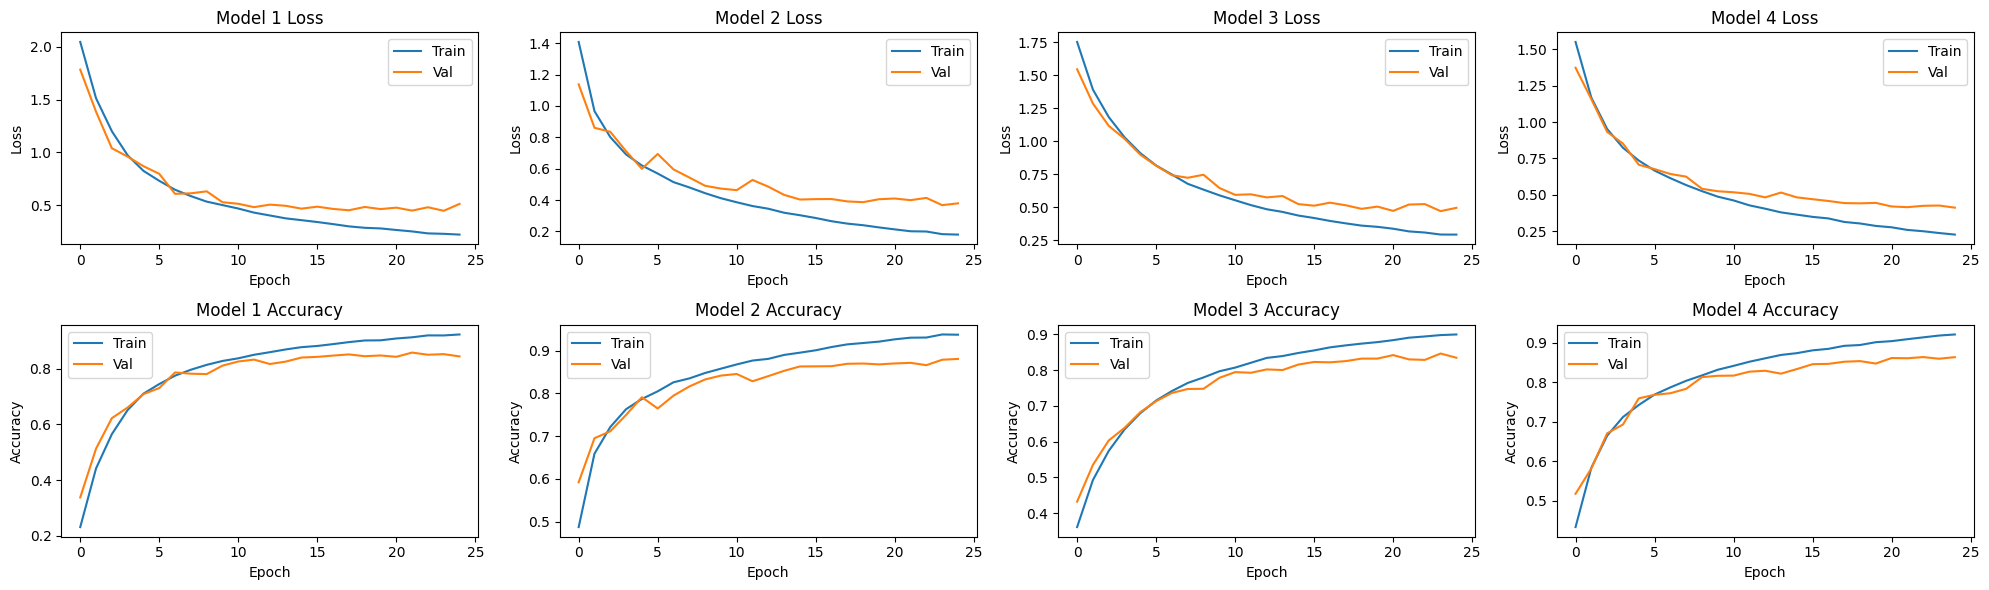

In [ ]:
results = [result_1, result_2, result_3, result_4]
names = ["Model 1", "Model 2", "Model 3", "Model 4"]

fig, axes = plt.subplots(2, 4, figsize=(20, 6))

for i, result in enumerate(results):
    train_losses, train_accs, val_losses, val_accs = result

    axes[0, i].plot(train_losses, label="Train")
    axes[0, i].plot(val_losses, label="Val")
    axes[0, i].set_title(f"{names[i]} Loss")
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].set_ylabel("Loss")
    axes[0, i].legend()

    axes[1, i].plot(train_accs, label="Train")
    axes[1, i].plot(val_accs, label="Val")
    axes[1, i].set_title(f"{names[i]} Accuracy")
    axes[1, i].set_xlabel("Epoch")
    axes[1, i].set_ylabel("Accuracy")
    axes[1, i].legend()

plt.tight_layout()
plt.show()

## Pick the best model

Choose the model with the lowest _validation loss_ among all 4 models. From now on, you are going to use this model for the following sections.

**Note**: Your best model should reach a reasonable accuracy on the validation set (at least 65% accuracy).



## My best model is Model_2 with:
Val Loss: 0.3631, Acc: 88.12%


In [ ]:
# TODO: Save the model with the lowest validation loss (or don't)
# best_model = Model_2()
# best_model.load_state_dict(torch.load("best_model_2.pth"))
# best_model.eval()
# device = "cuda" if torch.cuda.is_available() else "cpu"
# best_model.to(device)

### ❓ Discussion 1: The Effect of Batch Normalization

Compare the training curves (loss and accuracy) of **Model_1** (Simple CNN) and **Model_2** (with Batch Normalization).
1. **Convergence Speed:** Did Model_2 reach high accuracy faster (in fewer epochs) than Model_1? Why do you think that happens?
2. **Stability:** Look at the *validation loss* graph. Is Model_2's curve smoother or more jagged than Model_1's?
3. **Theory:** Explain in your own words how Batch Normalization helps with the "Internal Covariate Shift" problem. How does it affect the learning rate we can use?

<span style="color: teal; font-weight:bold;">
**YOUR ANSWER:**

1. Yes, Batch Normalization normalizes the data within each mini-batch, This process keeps the inputs to each layer of the network in a stable range so the network trains more efficiently, more stable and faster.

2. It's smoother beacuse Batch Normalization makes sure outputs of each layer stay steady as model learns so training will be more stable and smooth.

3. When input data propagates through the network, the distribution of each layer's inputs changes and network should adjust the weights to these changes, Batch Normalization normalizes outputs of each layer with average = 0 and variance = 1 and then scale them so distribution of each layer's inputs will remain more stable.
3.2 We can use higher learning rates without the risk of divergence beacuse Batch Normalization will normalize the outputs in a stable and gradients wont be too large.
</span>

### ❓ Discussion 2: Skip Connections & ResNets

You added "Skip Connections" to create **Model_3**.
1. **Vanishing Gradient:** Explain how skip connections help alleviate the "Vanishing Gradient" problem in very deep networks.
2. **Performance Check:** Did Model_3 outperform Model_2 on this specific dataset (CIFAR-10)?
    * *If yes:* Why was the extra complexity necessary?
    * *If no:* Why might a ResNet not be necessary for a network of this depth or a dataset of this complexity? (Hint: Is the network "deep" enough to suffer from degradation?)

<span style="color: teal; font-weight:bold;">
**YOUR ANSWER:**

1. In deep network during backpropagation gradients going through many layers can become small and learning of early layers would be slow, skip connections allow the output from the previous layer to be added directly to the output of a further layer so gradient can flow directly from later layers to earlier layers so gradient won't be too small.

2. Not actually, the best model with lowest validation loss was model_2, the network is not that deep so we won't have the Vanishing Gradient problem, making the model more complex will make overfitting easier on this dataset and will slow the training too.
</span>



# Dropout, Optimizers, Feature Space, and More

## Effect of Dropout

In this subsection, you are going to add dropout to your best architecture to see if the model could be improved further. Apply dropout to the classifier head (before the final linear layer) and train your best model architecture (from scratch) using the same configuration. Try to find a value for the dropout rate that improves the model's validation loss. You may not find a suitable dropout rate that actually makes validation loss go lower, but you should report at least 3 tried dropout rates.

**Note**: You can add dropout after `ReLU(BatchNorm(Conv(x)))` as well, but that's up to you (not needed for this homework).

**Note**: Train your model with the dropout rate that best increased your model's validation loss and use that going forward.

# Final Model

In [44]:
class FinalModel(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.flatten = nn.Flatten()

        self.block4 = nn.Sequential(
          nn.Linear(256 * 4 * 4, 256),
          nn.ReLU(),
          nn.Dropout(dropout_rate)
        )

        self.output = nn.Linear(256, 10)

    def forward_features(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.block4(x)
        return x

    def forward(self, x):
        features = self.forward_features(x)
        output = self.output(features)
        return output

# Train with 3 dropout

In [45]:
dropout_rates = [0.1, 0.3, 0.5]
dropout_results = {}

for dropout_rate in dropout_rates:
    model = FinalModel(dropout_rate).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    model_name = f"FinalModel_dropout_{int(dropout_rate*100)}"
    print(f"\nTraining {model_name}")

    result = train(
        train_dataloader,
        val_dataloader,
        model,
        loss_fn,
        optimizer,
        epochs,
        patience=5,
        model_name=model_name
    )

    dropout_results[dropout_rate] = result


Training FinalModel_dropout_10
Epoch [1/25]
Train Loss: 1.4457, Train Acc: 47.24%
Val   Loss: 1.2084, Val   Acc: 57.28%

Epoch [2/25]
Train Loss: 1.0168, Train Acc: 64.09%
Val   Loss: 0.9962, Val   Acc: 65.18%

Epoch [3/25]
Train Loss: 0.8387, Train Acc: 70.79%
Val   Loss: 0.8886, Val   Acc: 70.00%

Epoch [4/25]
Train Loss: 0.7435, Train Acc: 74.55%
Val   Loss: 0.7003, Val   Acc: 75.52%

Epoch [5/25]
Train Loss: 0.6659, Train Acc: 77.24%
Val   Loss: 0.9094, Val   Acc: 69.24%

Epoch [6/25]
Train Loss: 0.6106, Train Acc: 79.14%
Val   Loss: 0.6494, Val   Acc: 77.62%

Epoch [7/25]
Train Loss: 0.5510, Train Acc: 80.87%
Val   Loss: 0.5827, Val   Acc: 79.72%

Epoch [8/25]
Train Loss: 0.5234, Train Acc: 82.29%
Val   Loss: 0.5419, Val   Acc: 81.72%

Epoch [9/25]
Train Loss: 0.4787, Train Acc: 83.63%
Val   Loss: 0.5170, Val   Acc: 82.64%

Epoch [10/25]
Train Loss: 0.4509, Train Acc: 84.69%
Val   Loss: 0.5637, Val   Acc: 80.58%

Epoch [11/25]
Train Loss: 0.4254, Train Acc: 85.54%
Val   Loss: 0.5

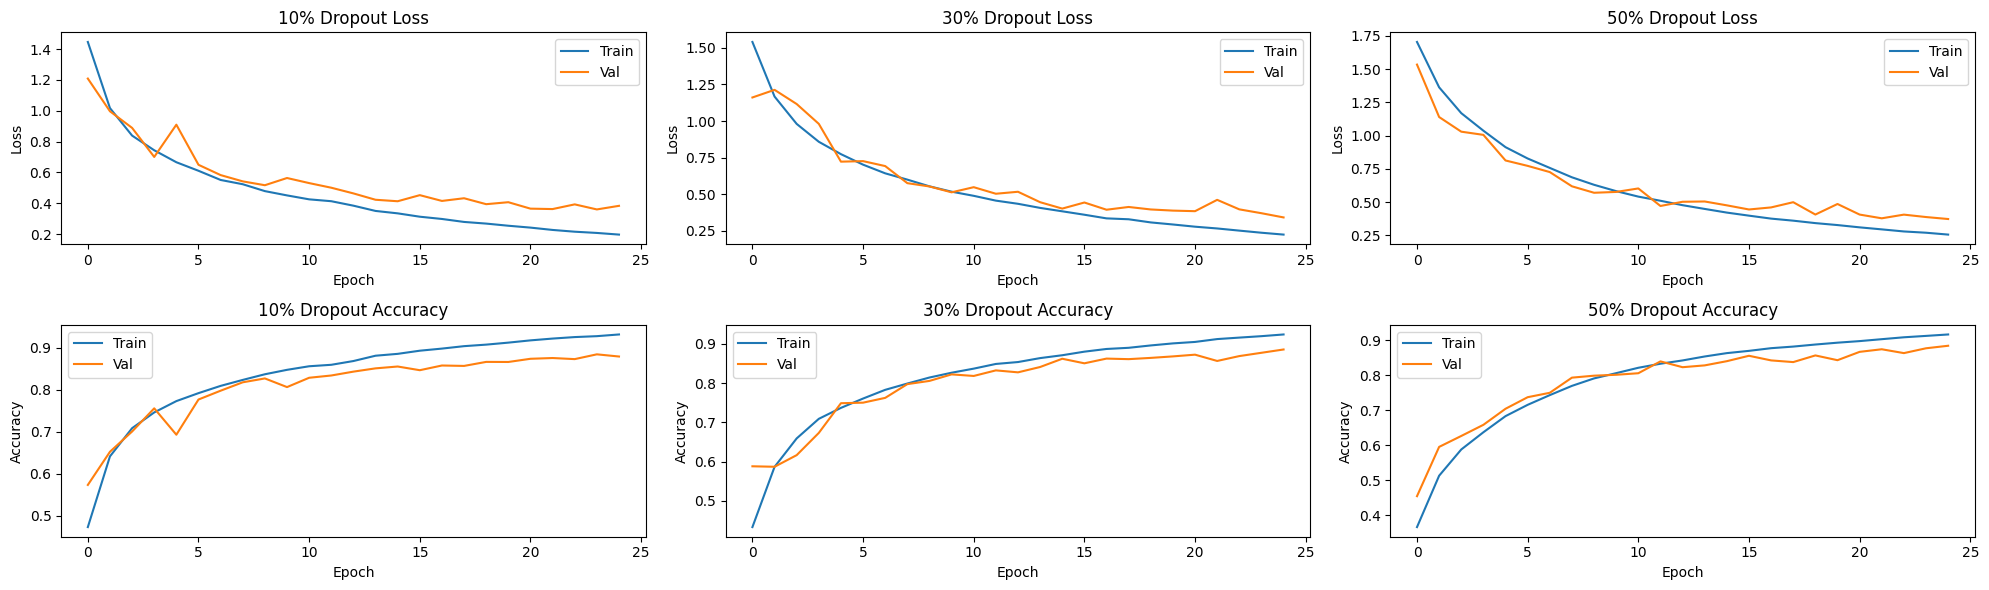

In [46]:
names = ["10% Dropout", "30% Dropout", "50% Dropout"]
dropout_rates = [0.1, 0.3, 0.5]

fig, axes = plt.subplots(2, 3, figsize=(20, 6))

for i, dr in enumerate(dropout_rates):
    result = dropout_results[dr]
    train_losses, train_accs, val_losses, val_accs = result

    axes[0, i].plot(train_losses, label="Train")
    axes[0, i].plot(val_losses, label="Val")
    axes[0, i].set_title(f"{names[i]} Loss")
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].set_ylabel("Loss")
    axes[0, i].legend()

    axes[1, i].plot(train_accs, label="Train")
    axes[1, i].plot(val_accs, label="Val")
    axes[1, i].set_title(f"{names[i]} Accuracy")
    axes[1, i].set_xlabel("Epoch")
    axes[1, i].set_ylabel("Accuracy")
    axes[1, i].legend()

plt.tight_layout()
plt.show()

<span style="color: teal; font-weight:bold;">

# 30% Dropout helped us to achive

Val   Loss: 0.3555, Val   Acc: 87.66%

its a little better than the model without dropout and it's a little faster.

</span>

## Different optimizers

In this subsection, you are going to retrain your best model architecture (from scratch) using 4 different optimizers (mostly with PyTorch's default values):
- `SGD` with `weight_decay=0`, `momentum=0.9`, 'Nesterov=False`.
- `Adam` with `betas=(0.9, 0.999)`, `eps=1e-8`, `amsgrad=False`, `weight_decay=0`.
- `RMSProp` with `alpha=0.99`, `eps=1e-8`, `momentum=0`, `centered=False`, `weight_decay=0`.
- `AdaGrad` with `lr_decay=0`, `initial_accumulator_value=0`, `eps=1e-10`, `weight_decay=0`.

For each of the settings above, train with at least 3 different learning rate values (the learning rate value you used first time for finding the best model should be included) and plot the training and validation loss and accuracy curves.

# SGD

In [ ]:
sgd_learning_rates = [0.1, 0.01, 0.001]
sgd_results = {}

for lr in sgd_learning_rates:
    model = FinalModel(0.3).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=False, weight_decay=0)

    name = f"FinalModel_dropout_30_SGD_lr{lr}"
    print(f"\nTraining {name}")

    result = train(
        train_dataloader,
        val_dataloader,
        model,
        loss_fn,
        optimizer,
        epochs,
        patience=5,
        model_name=name
    )

    sgd_results[lr] = result


Training FinalModel_dropout_30_SGD_lr0.1
Epoch [1/25]
Train Loss: 2.3252, Train Acc: 10.10%
Val   Loss: 2.3050, Val   Acc: 10.02%

Epoch [2/25]
Train Loss: 2.3063, Train Acc: 9.95%
Val   Loss: 2.3044, Val   Acc: 9.42%

Epoch [3/25]
Train Loss: 2.3067, Train Acc: 9.95%
Val   Loss: 2.3052, Val   Acc: 9.76%

Epoch [4/25]
Train Loss: 2.3062, Train Acc: 9.94%
Val   Loss: 2.3069, Val   Acc: 10.28%

Epoch [5/25]
Train Loss: 2.3066, Train Acc: 9.71%
Val   Loss: 2.3040, Val   Acc: 9.76%

Epoch [6/25]
Train Loss: 2.3065, Train Acc: 10.01%
Val   Loss: 2.3036, Val   Acc: 10.64%

Epoch [7/25]
Train Loss: 2.3065, Train Acc: 9.74%
Val   Loss: 2.3097, Val   Acc: 9.76%

Epoch [8/25]
Train Loss: 2.3064, Train Acc: 10.02%
Val   Loss: 2.3069, Val   Acc: 9.76%

Epoch [9/25]
Train Loss: 2.3059, Train Acc: 10.33%
Val   Loss: 2.3069, Val   Acc: 9.42%

Epoch [10/25]
Train Loss: 2.3062, Train Acc: 9.90%
Val   Loss: 2.3042, Val   Acc: 10.00%

Early stopping at epoch 11

Training FinalModel_dropout_30_SGD_lr0.01

# Adam

In [ ]:
adam_lrs = [0.1, 0.01, 0.001]
adam_results = {}

for lr in adam_lrs:
    model = FinalModel(0.3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-8, amsgrad=False, weight_decay=0)

    name = f"FinalModel_dropout_30_Adam_lr{lr}"
    print(f"\nTraining {name}")

    result = train(
        train_dataloader,
        val_dataloader,
        model,
        loss_fn,
        optimizer,
        epochs,
        patience=5,
        model_name=name
    )

    adam_results[lr] = result


Training FinalModel_dropout_30_Adam_lr0.1
Epoch [1/25]
Train Loss: 6.9037, Train Acc: 9.73%
Val   Loss: 2.3121, Val   Acc: 10.14%

Epoch [2/25]
Train Loss: 2.3108, Train Acc: 9.90%
Val   Loss: 2.3112, Val   Acc: 10.02%

Epoch [3/25]
Train Loss: 2.3109, Train Acc: 9.95%
Val   Loss: 2.3101, Val   Acc: 10.08%

Epoch [4/25]
Train Loss: 2.3117, Train Acc: 10.28%
Val   Loss: 2.3104, Val   Acc: 10.02%

Epoch [5/25]
Train Loss: 2.3120, Train Acc: 10.02%
Val   Loss: 2.3055, Val   Acc: 10.64%

Epoch [6/25]
Train Loss: 2.3118, Train Acc: 9.92%
Val   Loss: 2.3099, Val   Acc: 10.00%

Epoch [7/25]
Train Loss: 2.3128, Train Acc: 9.90%
Val   Loss: 2.3115, Val   Acc: 9.42%

Epoch [8/25]
Train Loss: 2.3124, Train Acc: 9.78%
Val   Loss: 2.3063, Val   Acc: 9.42%

Epoch [9/25]
Train Loss: 2.3119, Train Acc: 10.05%
Val   Loss: 2.3084, Val   Acc: 10.24%

Early stopping at epoch 10

Training FinalModel_dropout_30_Adam_lr0.01
Epoch [1/25]
Train Loss: 2.3667, Train Acc: 14.20%
Val   Loss: 2.0935, Val   Acc: 17

# RMSProp

In [ ]:
rms_lrs = [0.1, 0.01, 0.001]
rms_results = {}

for lr in rms_lrs:
    model = FinalModel(0.3).to(device)
    optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, alpha=0.99, eps=1e-8, momentum=0, centered=False, weight_decay=0)

    name = f"FinalModel_dropout_30_RMSprop_lr{lr}"
    print(f"\nTraining {name}")

    result = train(
        train_dataloader,
        val_dataloader,
        model,
        loss_fn,
        optimizer,
        epochs,
        patience=5,
        model_name=name
    )

    rms_results[lr] = result


Training FinalModel_dropout_30_RMSprop_lr0.1
Epoch [1/25]
Train Loss: 291.6351, Train Acc: 9.85%
Val   Loss: 2.3294, Val   Acc: 10.64%

Epoch [2/25]
Train Loss: 2.5189, Train Acc: 10.19%
Val   Loss: 2.3326, Val   Acc: 10.14%

Epoch [3/25]
Train Loss: 2.3132, Train Acc: 9.88%
Val   Loss: 2.3528, Val   Acc: 10.14%

Epoch [4/25]
Train Loss: 9.1024, Train Acc: 10.01%
Val   Loss: 2.3508, Val   Acc: 9.42%

Epoch [5/25]
Train Loss: 2.3130, Train Acc: 9.84%
Val   Loss: 2.3691, Val   Acc: 10.02%

Early stopping at epoch 6

Training FinalModel_dropout_30_RMSprop_lr0.01
Epoch [1/25]
Train Loss: 5.7268, Train Acc: 13.28%
Val   Loss: 2.1797, Val   Acc: 12.86%

Epoch [2/25]
Train Loss: 1.9606, Train Acc: 24.32%
Val   Loss: 1.7411, Val   Acc: 30.96%

Epoch [3/25]
Train Loss: 1.6036, Train Acc: 40.19%
Val   Loss: 2.0485, Val   Acc: 32.42%

Epoch [4/25]
Train Loss: 1.3581, Train Acc: 51.69%
Val   Loss: 1.5483, Val   Acc: 49.04%

Epoch [5/25]
Train Loss: 1.1679, Train Acc: 59.19%
Val   Loss: 1.9421, Va

# AdaGrad

In [ ]:
adagrad_lrs = [0.1, 0.01, 0.001]
adagrad_results = {}

for lr in adagrad_lrs:
    model = FinalModel(0.3).to(device)
    optimizer = torch.optim.Adagrad(model.parameters(), lr=lr, lr_decay=0, initial_accumulator_value=0, eps=1e-10, weight_decay=0)

    name = f"FinalModel_dropout_30_Adagrad_lr{lr}"
    print(f"\nTraining {name}")

    result = train(
        train_dataloader,
        val_dataloader,
        model,
        loss_fn,
        optimizer,
        epochs,
        patience=5,
        model_name=name
    )

    adagrad_results[lr] = result


Training FinalModel_dropout_30_Adagrad_lr0.1
Epoch [1/25]
Train Loss: 6.3956, Train Acc: 10.86%
Val   Loss: 2.2970, Val   Acc: 10.26%

Epoch [2/25]
Train Loss: 2.2810, Train Acc: 12.60%
Val   Loss: 2.2506, Val   Acc: 14.22%

Epoch [3/25]
Train Loss: 2.2455, Train Acc: 13.82%
Val   Loss: 2.2090, Val   Acc: 15.32%

Epoch [4/25]
Train Loss: 2.2168, Train Acc: 14.58%
Val   Loss: 2.1505, Val   Acc: 17.14%

Epoch [5/25]
Train Loss: 2.1902, Train Acc: 15.38%
Val   Loss: 2.1283, Val   Acc: 17.56%

Epoch [6/25]
Train Loss: 2.1571, Train Acc: 16.50%
Val   Loss: 2.0966, Val   Acc: 18.88%

Epoch [7/25]
Train Loss: 2.1088, Train Acc: 17.41%
Val   Loss: 2.0100, Val   Acc: 21.62%

Epoch [8/25]
Train Loss: 2.0726, Train Acc: 18.98%
Val   Loss: 2.2312, Val   Acc: 15.68%

Epoch [9/25]
Train Loss: 2.0443, Train Acc: 19.69%
Val   Loss: 2.0655, Val   Acc: 19.92%

Epoch [10/25]
Train Loss: 2.0078, Train Acc: 20.84%
Val   Loss: 1.9914, Val   Acc: 22.56%

Epoch [11/25]
Train Loss: 1.9886, Train Acc: 21.77%
V

In [ ]:
def plot_optimizer_results(results_dict, learning_rates, optimizer_name):
    n = len(learning_rates)
    fig, axes = plt.subplots(2, n, figsize=(6*n, 8))

    for i, lr in enumerate(learning_rates):
        train_losses, train_accs, val_losses, val_accs = results_dict[lr]

        axes[0, i].plot(train_losses, label="Train")
        axes[0, i].plot(val_losses, label="Val")
        axes[0, i].set_title(f"{optimizer_name} LR={lr} Loss")
        axes[0, i].set_xlabel("Epoch")
        axes[0, i].set_ylabel("Loss")
        axes[0, i].legend()

        axes[1, i].plot(train_accs, label="Train")
        axes[1, i].plot(val_accs, label="Val")
        axes[1, i].set_title(f"{optimizer_name} LR={lr} Accuracy")
        axes[1, i].set_xlabel("Epoch")
        axes[1, i].set_ylabel("Accuracy")
        axes[1, i].legend()

    plt.tight_layout()
    plt.show()

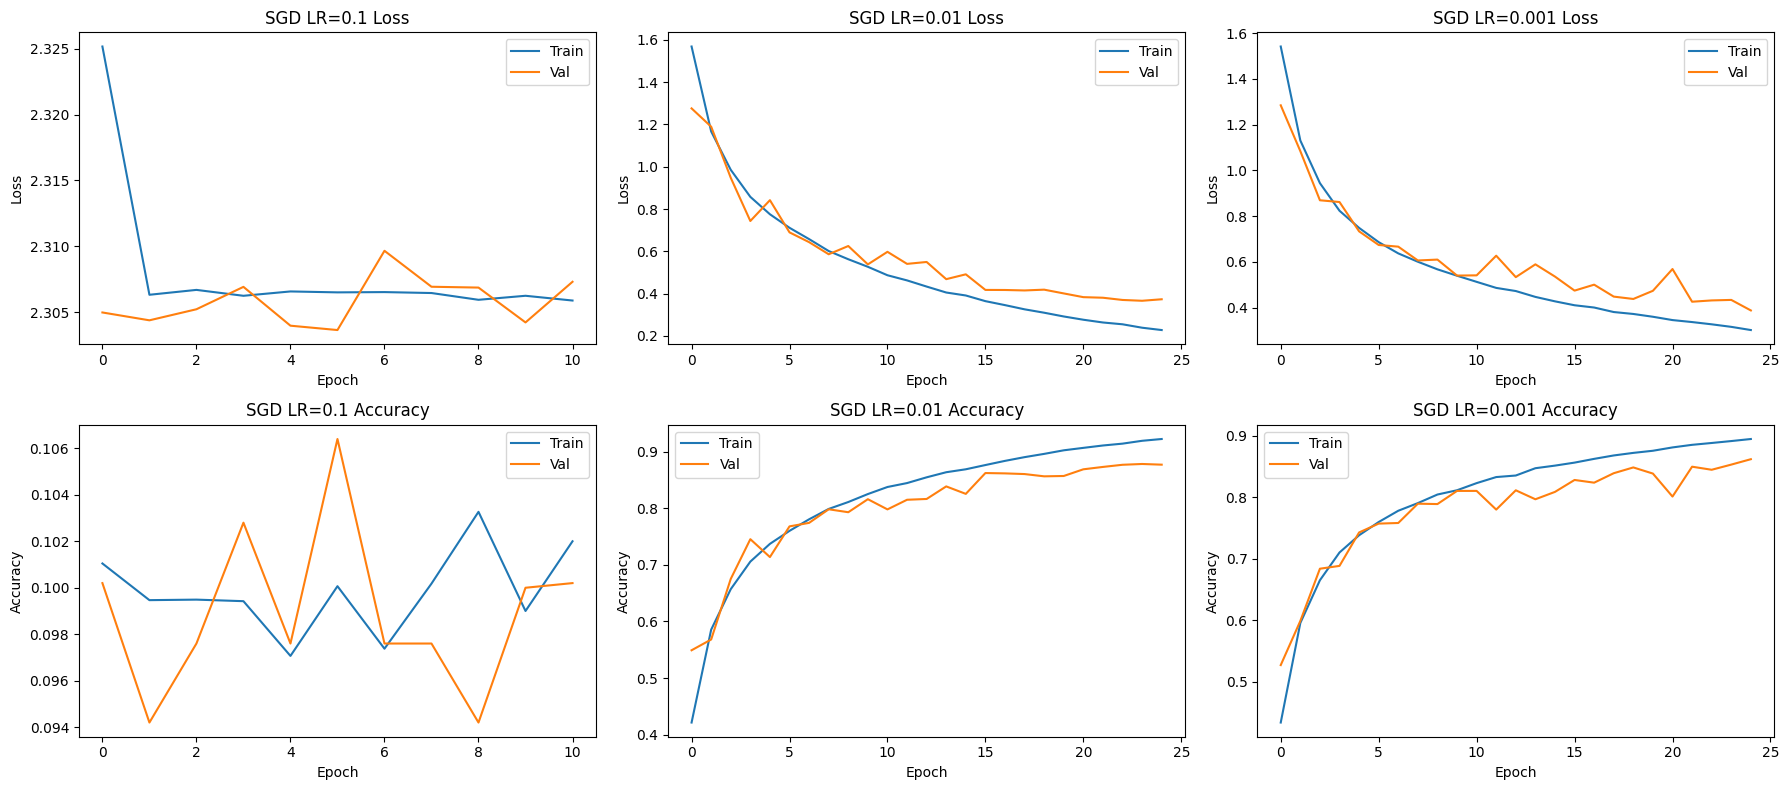

In [ ]:
plot_optimizer_results(sgd_results, sgd_learning_rates, "SGD")

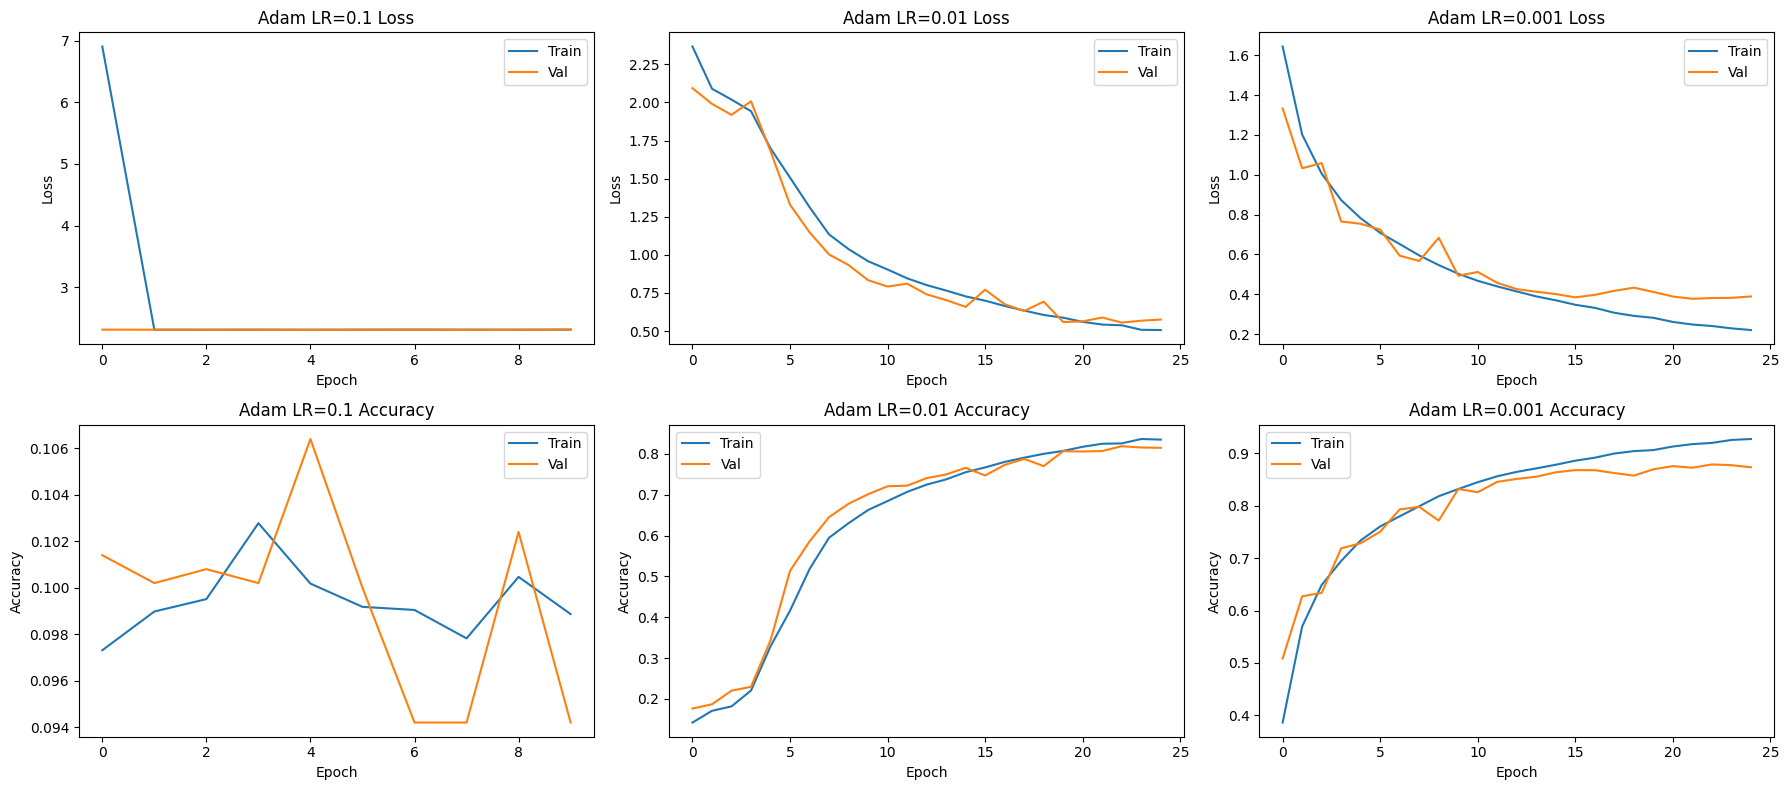

In [ ]:
plot_optimizer_results(adam_results, adam_lrs, "Adam")

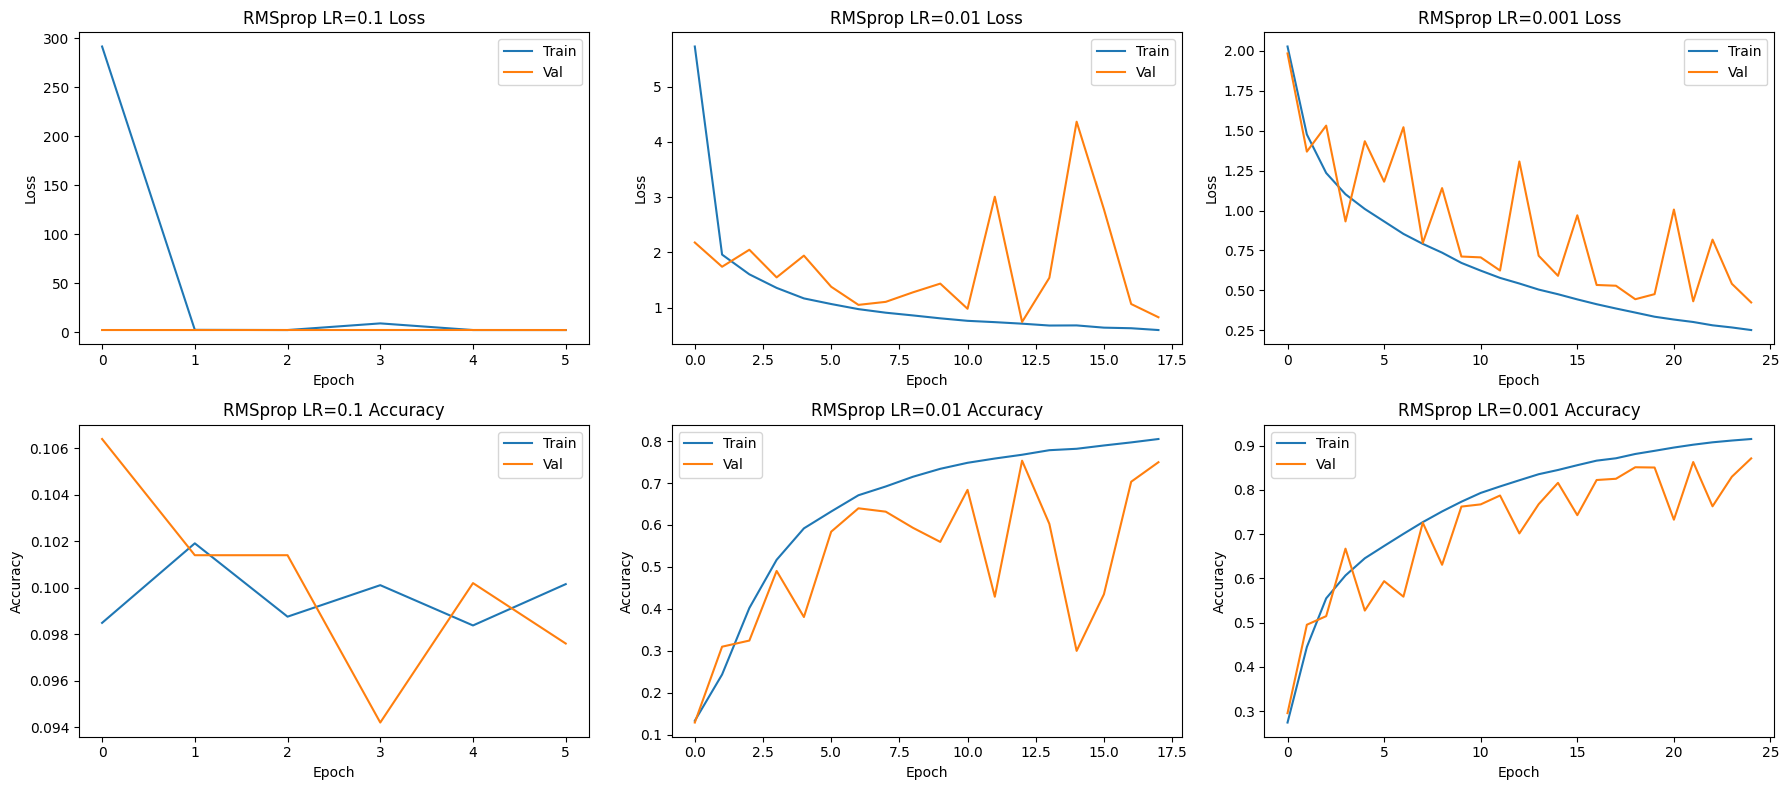

In [ ]:
plot_optimizer_results(rms_results, rms_lrs, "RMSprop")

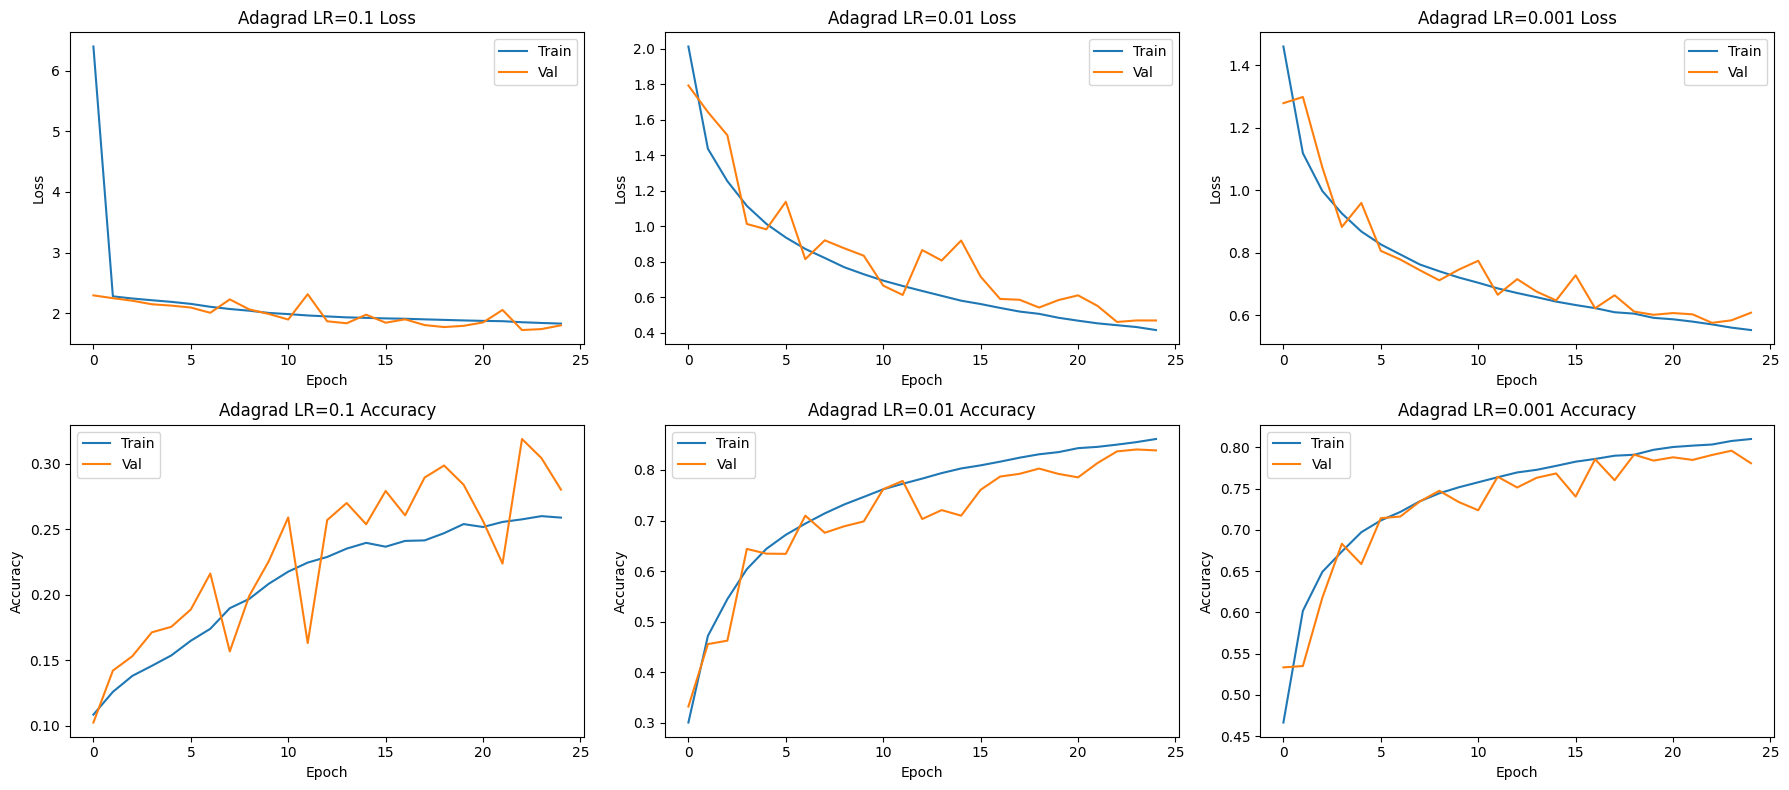

In [ ]:
plot_optimizer_results(adagrad_results, adagrad_lrs, "Adagrad")

### ❓ Discussion 3: Optimizers

Analyze the results of training your model with different optimizers. How do loss/accuracy curves differ from optimizer to optimizer and why?

<span style="color: teal; font-weight:bold;">

YOUR ANSWER:

1. Selecting a bad learning rate like 0.1 will affect all optimizers and as we see none of them will operate the way that we want

2. Picking a good learning rate like 0.01 for SGD or Adam will make them behave very better

3. As we can see the most smooth curve are the one with Adam (lr = 0.01 or lr = 0.001) other curves are zigzag-like (mostly in Adagrad and RMSProps)

4. Adagrad is kinda slower than the others beacuse of its nature, it sums all past gradient 5. The SGD curve is not as smooth as the Adam but it gives us the lowest loss with (lr = 0.01)

</span>

# Training best model once more

In [ ]:
model = FinalModel(0.3).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

name = f"FinalModel_dropout_30_SGD_lr0.01"
print(f"\nTraining {name}")

train(
    train_dataloader,
    val_dataloader,
    model,
    loss_fn,
    optimizer,
    epochs,
    patience=5,
    model_name=name
)


Training FinalModel_dropout_30_SGD_lr0.01
Epoch [1/25]
Train Loss: 1.5277, Train Acc: 43.98%
Val   Loss: 1.3087, Val   Acc: 52.28%

Epoch [2/25]
Train Loss: 1.1582, Train Acc: 59.47%
Val   Loss: 1.0718, Val   Acc: 62.80%

Epoch [3/25]
Train Loss: 0.9714, Train Acc: 66.36%
Val   Loss: 0.8514, Val   Acc: 70.56%

Epoch [4/25]
Train Loss: 0.8639, Train Acc: 70.42%
Val   Loss: 0.8410, Val   Acc: 69.70%

Epoch [5/25]
Train Loss: 0.7702, Train Acc: 73.86%
Val   Loss: 0.7181, Val   Acc: 73.98%

Epoch [6/25]
Train Loss: 0.7054, Train Acc: 76.40%
Val   Loss: 0.6516, Val   Acc: 77.28%

Epoch [7/25]
Train Loss: 0.6521, Train Acc: 78.00%
Val   Loss: 0.5926, Val   Acc: 78.98%

Epoch [8/25]
Train Loss: 0.6058, Train Acc: 79.64%
Val   Loss: 0.5776, Val   Acc: 79.90%

Epoch [9/25]
Train Loss: 0.5605, Train Acc: 81.31%
Val   Loss: 0.6432, Val   Acc: 78.62%

Epoch [10/25]
Train Loss: 0.5256, Train Acc: 82.45%
Val   Loss: 0.5131, Val   Acc: 82.32%

Epoch [11/25]
Train Loss: 0.4928, Train Acc: 83.53%
Val 

[[1.5276906638490884,
  1.1582199603488499,
  0.971433661878109,
  0.8638797034932808,
  0.7702008976008404,
  0.7054336704313755,
  0.65210063603114,
  0.6057976645163514,
  0.5605028652035716,
  0.5256334568627856,
  0.4928049386944622,
  0.4687813752203841,
  0.436103394551372,
  0.41205800500359724,
  0.38893229635009036,
  0.36589372325265274,
  0.34798662460790103,
  0.3332180070944808,
  0.3197863624029031,
  0.3024076338307085,
  0.2832963012730364,
  0.2746527350761674,
  0.25867408378028567,
  0.24200495525093918,
  0.2353760877423073],
 [0.4398444444444444,
  0.5947111111111111,
  0.6636444444444445,
  0.7042,
  0.7385555555555555,
  0.7639555555555556,
  0.78,
  0.7964222222222223,
  0.8131333333333334,
  0.8244666666666667,
  0.8352666666666667,
  0.8427333333333333,
  0.8527333333333333,
  0.8614888888888889,
  0.8695555555555555,
  0.8765333333333334,
  0.8822,
  0.8885111111111111,
  0.8908,
  0.8991111111111111,
  0.9051777777777777,
  0.9080666666666667,
  0.911266666

# Saving the final model

In [ ]:
torch.save(model.state_dict(), f"final_best_model.pt")

## Evalution

Test your best trained model (using the Test Dataloader that you have).

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FinalModel(0.3).to(device)
model.load_state_dict(torch.load("final_best_model.pt", map_location=device))
model.eval()

FinalModel(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(

In [17]:
def evaluate_model(dataloader, model, device, loss_fn=None, collect_wrong=True):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    wrong_samples = [] if collect_wrong else None

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)

            logits = model(X)
            preds = logits.argmax(1)

            if loss_fn is not None:
                total_loss += loss_fn(logits, y).item()

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

            if collect_wrong:
                mism = preds != y
                if mism.any():
                    Xw = X[mism].cpu()
                    yw = y[mism].cpu()
                    pw = preds[mism].cpu()
                    for i in range(Xw.size(0)):
                        wrong_samples.append((Xw[i], int(yw[i]), int(pw[i])))

    avg_loss = (total_loss / len(dataloader)) if loss_fn is not None else None
    acc = correct / total

    return {
        "loss": avg_loss,
        "acc": acc,
        "preds": torch.cat(all_preds),
        "labels": torch.cat(all_labels),
        "wrong_samples": wrong_samples
    }

In [18]:
out = evaluate_model(
    dataloader=test_dataloader,
    model=model,
    device=device,
    loss_fn=loss_fn,
    collect_wrong=True
)

print(f"Test Loss: {out['loss']:.4f}")
print(f"Test Acc : {out['acc']*100:.2f}%")

Test Loss: 0.4307
Test Acc : 87.05%


### Visualize incorrectly predicted samples from testset

Visualize *20* random images from testset that are incorrectly predicted by the model. Note that if you used normalization in the transform function for loading the data, you will need to unnormalize the images before displaying them.

In [19]:
CIFAR10_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR10_STD  = [0.2023, 0.1994, 0.2010]

def unnormalize(img, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    mean = torch.tensor(mean).view(-1, 1, 1)
    std = torch.tensor(std).view(-1, 1, 1)
    return img * std + mean

def plot_wrong_predictions(wrong_samples, class_names, n=20):
    if not wrong_samples:
        print("No wrong predictions.")
        return

    n = min(n, len(wrong_samples))
    idxs = np.random.choice(len(wrong_samples), size=n, replace=False)

    cols = 5
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 3.2, rows * 3.2))

    for k, idx in enumerate(idxs, start=1):
        img, y_true, y_pred = wrong_samples[idx]

        img = unnormalize(img).clamp(0, 1)
        img_np = img.permute(1, 2, 0).numpy()

        plt.subplot(rows, cols, k)
        plt.imshow(img_np)
        plt.axis("off")
        plt.title(f"True: {class_names[y_true]}\nPred: {class_names[y_pred]}", fontsize=10)

    plt.tight_layout()
    plt.show()

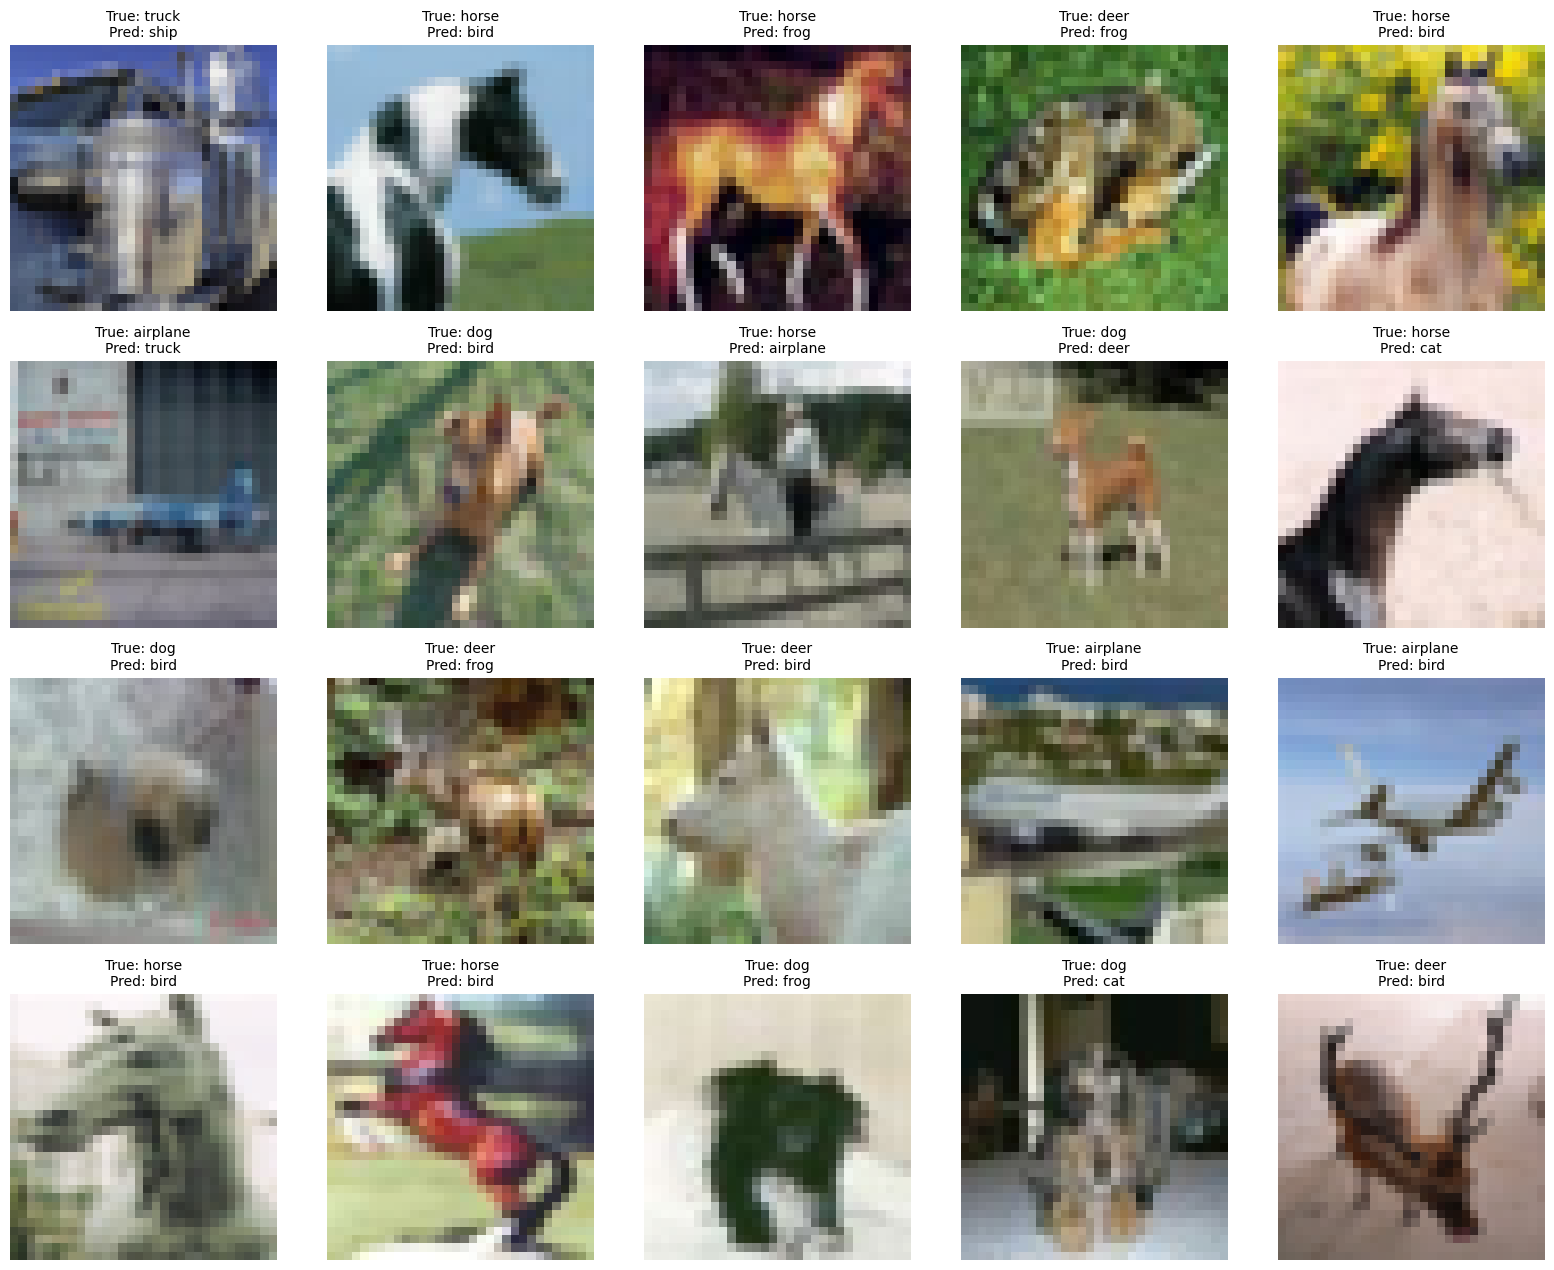

In [20]:
plot_wrong_predictions(out["wrong_samples"], class_names=test_dataset.classes, n=20)

### Get classification report

Print the classification report on test set, showing per-class precision, recall, and F1-score.

In [21]:
print(classification_report(
    out["labels"].numpy(),
    out["preds"].numpy(),
    target_names=test_dataset.classes,
    digits=4
))

              precision    recall  f1-score   support

    airplane     0.8980    0.8800    0.8889      1000
  automobile     0.9270    0.9650    0.9456      1000
        bird     0.6591    0.9300    0.7715      1000
         cat     0.8049    0.7550    0.7792      1000
        deer     0.8695    0.8530    0.8612      1000
         dog     0.9214    0.7390    0.8202      1000
        frog     0.8941    0.9030    0.8985      1000
       horse     0.9612    0.8420    0.8977      1000
        ship     0.9353    0.9390    0.9371      1000
       truck     0.9394    0.8990    0.9188      1000

    accuracy                         0.8705     10000
   macro avg     0.8810    0.8705    0.8719     10000
weighted avg     0.8810    0.8705    0.8719     10000



# Confusion Matrix


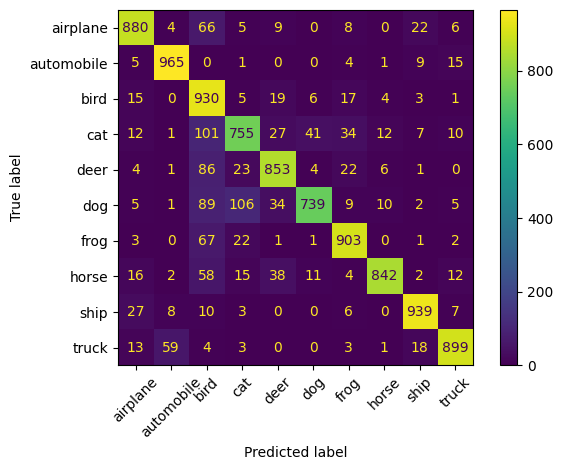

In [22]:
cm = confusion_matrix(out["labels"].numpy(), out["preds"].numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)

disp.plot(xticks_rotation=45, values_format="d")
plt.tight_layout()
plt.show()

### ❓ Discussion 4: Error Analysis

Look at the images you visualized in the "Visualize incorrectly predicted samples" section and your classification report.
1. **Confused Classes:** Which two classes does your model confuse the most? (e.g., Does it often mistake 'cats' for 'dogs' or 'planes' for 'birds'?)
2. **Visual Inspection:** Look at the misclassified images. Can *you* (as a human) easily tell what class they belong to, or are they blurry/ambiguous?
3. **Pattern:** Do the errors share a common trait? (e.g., dark background, small object size, obstruction?)

<span style="color: teal; font-weight:bold;">
**YOUR ANSWER:**

1.

dog -> cat (106)

cat -> bird (101)

dog -> bird (89)

2.

Not all of them, some of them are hard to tell. for example the pic in row 1 column 1 can not be told that its a truck or a ship, or the picture in last row middle column is more like a frog actually but the true lable is dog

3.

I think maybe a lot of them are pictures with lots of details in background, most of pics in row one has a lot of details in the background so it confuses the model, same shape can make the prediction hard to for example that dog -> frog shape is more like a frog, maybe the small shape make me think of this.
</span>





## Exploring the feature space (embedding layer)

### Calculate the feature space for all training samples

You have trained and evaluated your model. Now, for each sample in the trainset, calculate its "feature space" discussed in the model section. The result of this section should be a tensor of size `(50000, N)` saved in a variable (for later usage)

- **Hint 1:** define a tensor with dimension `(50000, N)` where *50000* is the size of the trainset and *N* is the dimension of the feature space

- **Hint 2:** Pay attention to the `shuffle` attribute of your train dataloader (If needed)

In [23]:
model.eval()

full_train_dataset = train_and_val_data

feature_loader = DataLoader(
    full_train_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

N = 256

features = torch.empty((len(full_train_dataset), N), dtype=torch.float32)

idx = 0
with torch.no_grad():
    for X, _ in feature_loader:
        X = X.to(device)

        feats = model.forward_features(X)
        bsz = feats.size(0)

        features[idx:idx+bsz] = feats.cpu()
        idx += bsz

print("Feature tensor shape:", features.shape)

Feature tensor shape: torch.Size([50000, 256])


### K Nearest Neighbor in feature space

You already have calculated the feature spaces for trainset ($S$) in the previous section

1. Get 5 random samples from testset which are correctly predicted by the model.
2. For each sample, calculate its "feature map" ($X$).
3. For each sample, calculate its *5* nearest neighbors in "feature space" in the trainset (by comparing $X$ to each row in $S$) and visualize them.

**Note:** To find the nearest neighbors in the feature space, you can use any library of your choice.

In [24]:
train_viz_dataset = datasets.CIFAR10(
    root="data", train=True, download=True, transform=transforms.ToTensor()
)
test_viz_dataset = datasets.CIFAR10(
    root="data", train=False, download=True, transform=transforms.ToTensor()
)

train_labels = np.array(train_and_val_data.targets)

model.eval()
correct_pool = []

global_idx = 0
with torch.no_grad():
    for X, y in test_dataloader:
        X = X.to(device)
        y = y.to(device)

        preds = model(X).argmax(1)

        X_cpu = X.cpu()
        y_cpu = y.cpu()
        p_cpu = preds.cpu()

        for i in range(X_cpu.size(0)):
            if p_cpu[i].item() == y_cpu[i].item():
                test_index = global_idx + i
                correct_pool.append((test_index, int(y_cpu[i]), int(p_cpu[i]), X_cpu[i]))

        global_idx += X_cpu.size(0)

rng = np.random.default_rng(0)
chosen_ids = rng.choice(len(correct_pool), size=5, replace=False)
chosen_samples = [correct_pool[i] for i in chosen_ids]

print(f"Found {len(correct_pool)} correctly predicted test samples. Using 5 random ones.")

Found 8705 correctly predicted test samples. Using 5 random ones.


In [25]:
def visualize_query_and_neighbors(test_index, y_true, y_pred, nn_indices):
    q_img, _ = test_viz_dataset[test_index]

    plt.figure(figsize=(12, 3))

    plt.subplot(1, 6, 1)
    plt.imshow(q_img.permute(1, 2, 0))
    plt.axis("off")
    plt.title(f"QUERY\nT:{classes[y_true]}\nP:{classes[y_pred]}", fontsize=9)

    for j, tr_idx in enumerate(nn_indices, start=2):
        n_img, _ = train_viz_dataset[tr_idx]
        n_label = train_labels[tr_idx]

        plt.subplot(1, 6, j)
        plt.imshow(n_img.permute(1, 2, 0))
        plt.axis("off")
        plt.title(f"NN{j-1}\n{classes[n_label]}\nidx:{tr_idx}", fontsize=9)

    plt.tight_layout()
    plt.show()

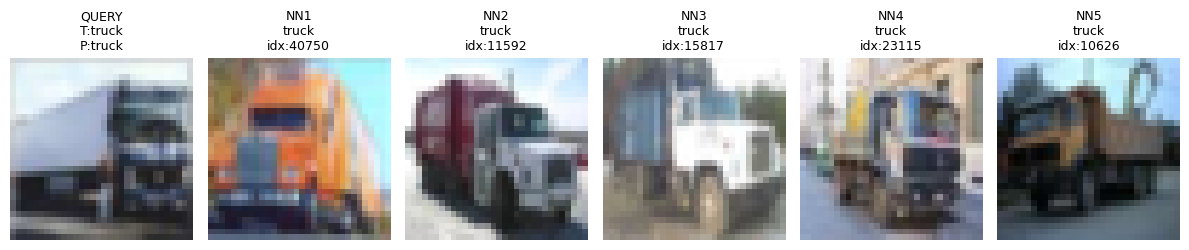

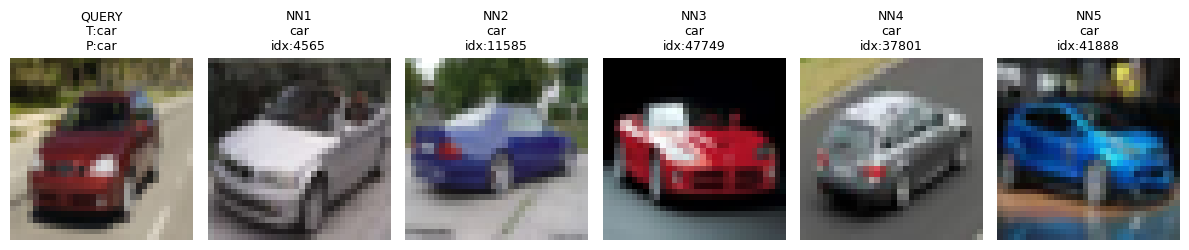

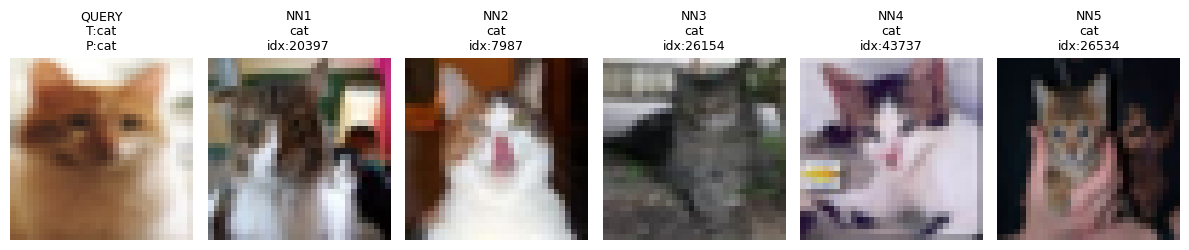

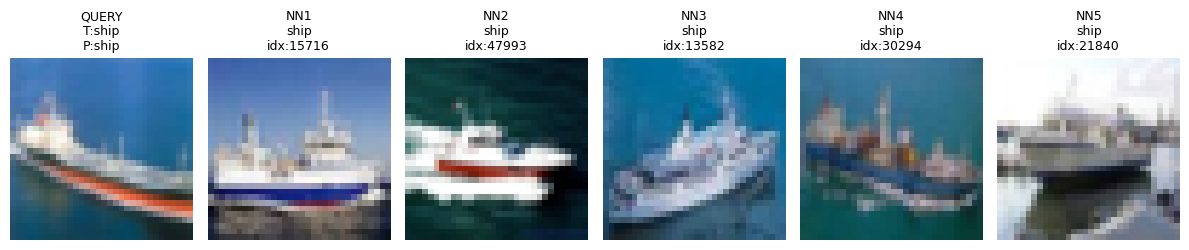

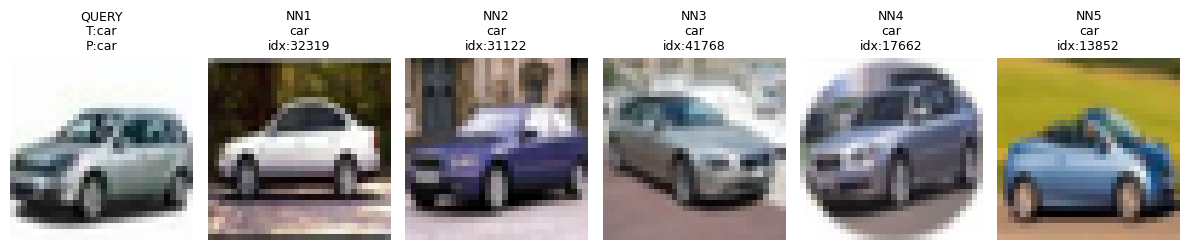

In [26]:
S = features.cpu().numpy()
knn = NearestNeighbors(n_neighbors=5, metric="euclidean")
knn.fit(S)

with torch.no_grad():
    for (test_index, y_true, y_pred, x_norm_cpu) in chosen_samples:
        x_in = x_norm_cpu.unsqueeze(0).to(device)
        x_feat = model.forward_features(x_in).cpu().numpy()

        dists, inds = knn.kneighbors(x_feat, n_neighbors=5, return_distance=True)
        nn_indices = inds[0]

        visualize_query_and_neighbors(test_index, y_true, y_pred, nn_indices)

### TSNE

1. Sample $M$ ($2500$ would be enough) random samples from the trainset feature space (calculated in the above sections)
2. Now you have a vector of size `(M, N)` where $N$ is the dimension of the feature space
3. Using TSNE reduce $N$ to $2$ (Now you have a vector of size `(M, 2)`)
4. Print the shape of the output

**Hint:** You can use `sklearn.manifold.TSNE`

In [30]:
M = 2500
rng = np.random.default_rng(0)
idxs = rng.choice(features.shape[0], size=M, replace=False)
X = features[idxs].cpu().numpy()
y = np.array(train_and_val_data.targets)[idxs]
classes = train_and_val_data.classes

tsne = TSNE(n_components=2, perplexity=30, init="pca",
            learning_rate="auto", random_state=0)
X_2d = tsne.fit_transform(X)

print("Input shape :", X.shape)
print("Output shape:", X_2d.shape)

Input shape : (2500, 256)
Output shape: (2500, 2)


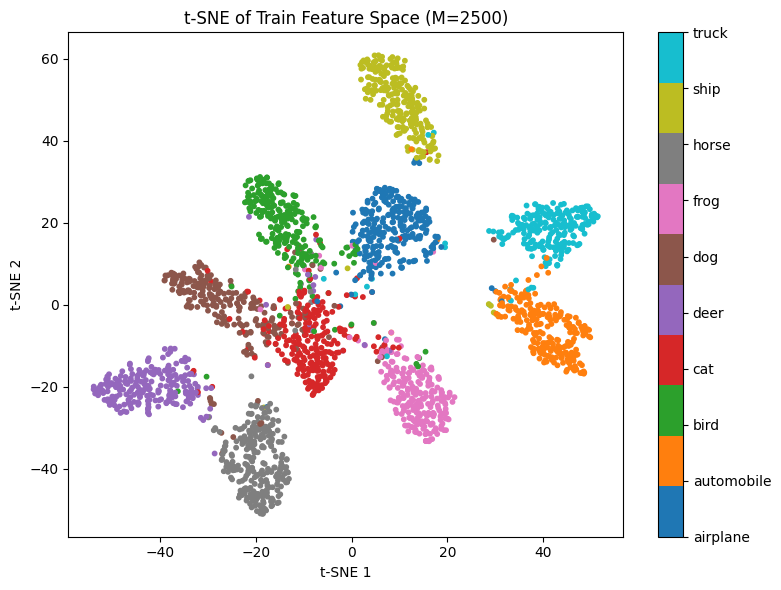

In [31]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, s=10, cmap="tab10")
plt.title("t-SNE of Train Feature Space (M=2500)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

cbar = plt.colorbar(sc, ticks=range(10))
cbar.ax.set_yticklabels(classes)
plt.tight_layout()
plt.show()

<span style="color: teal; font-weight:bold;">

# 🐈 As we see we have good sepration but for example cat, bird and dog have lots of data points that are too close, that is why our confusion matrix result that. 🐈

</span>

# Model Interpretability - Grad-CAM


A central problem in deep learning research is explaining how highly complex models arrive at their predictions. Convolutional neural networks (CNNs) have achieved remarkable results in image classification and recognition. However, their internal decision-making mechanisms are often not clear to us. Because it is difficult to determine why a CNN assigns a specific label to an image, we usually refer to them as "black boxes". To address this issue, several interpretability techniques have been proposed. Grad-CAM (Gradient-weighted Class Activation Mapping) is one of the most influential approaches in computer vision, first presented by Selvaraju et al. in 2017 titled [*"Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization"*](https://arxiv.org/abs/1610.02391).

Grad-CAM provides us with a way to identify and visualize the regions of an image that most strongly affect a CNN's prediction for a given class. For example, when a trained network classifies an image as belonging to a category such as "cat", Grad-CAM reveals the areas of the image that contributed the most to that decision. The method operates by using gradient information, (specifically, the gradients of the target class score with respect to feature maps in intermediate convolutional layers) to produce a class-discriminative heatmap. This heatmap highlights the spatial locations that have the greatest impact on the model's output, therefore, showing us what visual cues/patterns the model relies on.

![GradCam example for Classify a photo as a Cat.](https://dlhr.de/assets/8-0.jpg)

**Grad-CAM Implementation and Visualization**

Now, you will mplement Grad-CAM to visualize highly influential regions of CIFAR-10 test images that impact the predictions of your trained model. Use the provided Grad-CAM code to:

1. Load the best-performing model (based on validation accuracy) trained on CIFAR-10.
2. Select 5 random test samples per class (10 classes, 50 samples total) from the CIFAR-10 **test set**.
3. Generate Grad-CAM heatmaps for each sample, using the last convolutional layer as the target layer and the model's predicted class as the target class.
4. Visualize the results in a 5x10 subplot, overlaying each heatmap on the **original** image.(Display heatmaps using a JET colormap with 40% transparency (`alpha=0.4`).) Include true and predicted labels in the subplot titles, highlighting mismatches in red.

**NOTICE**: You are not allowed to use 3rd party ready to use libraries for implementation of Grad-CAM!

In [32]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.h1 = target_layer.register_forward_hook(self._forward_hook)
        self.h2 = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)

        logits = self.model(x)
        pred_idx = int(logits.argmax(1).item())

        if class_idx is None:
            class_idx = pred_idx

        score = logits[0, class_idx]
        score.backward(retain_graph=False)

        A = self.activations
        dA = self.gradients

        weights = dA.mean(dim=(2, 3), keepdim=True)

        cam = (weights * A).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(cam, size=(32, 32), mode="bilinear", align_corners=False)

        cam = cam[0, 0]

        cam_min, cam_max = cam.min(), cam.max()
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        return cam.detach().cpu().numpy(), pred_idx

    def close(self):
        self.h1.remove()
        self.h2.remove()

In [33]:
model.eval()

target_layer = model.block3[3]

targets = np.array(test_dataset.targets)
rng = np.random.default_rng(0)

selected = {}
for c in range(10):
    idxs = np.where(targets == c)[0]
    selected[c] = rng.choice(idxs, size=5, replace=False).tolist()

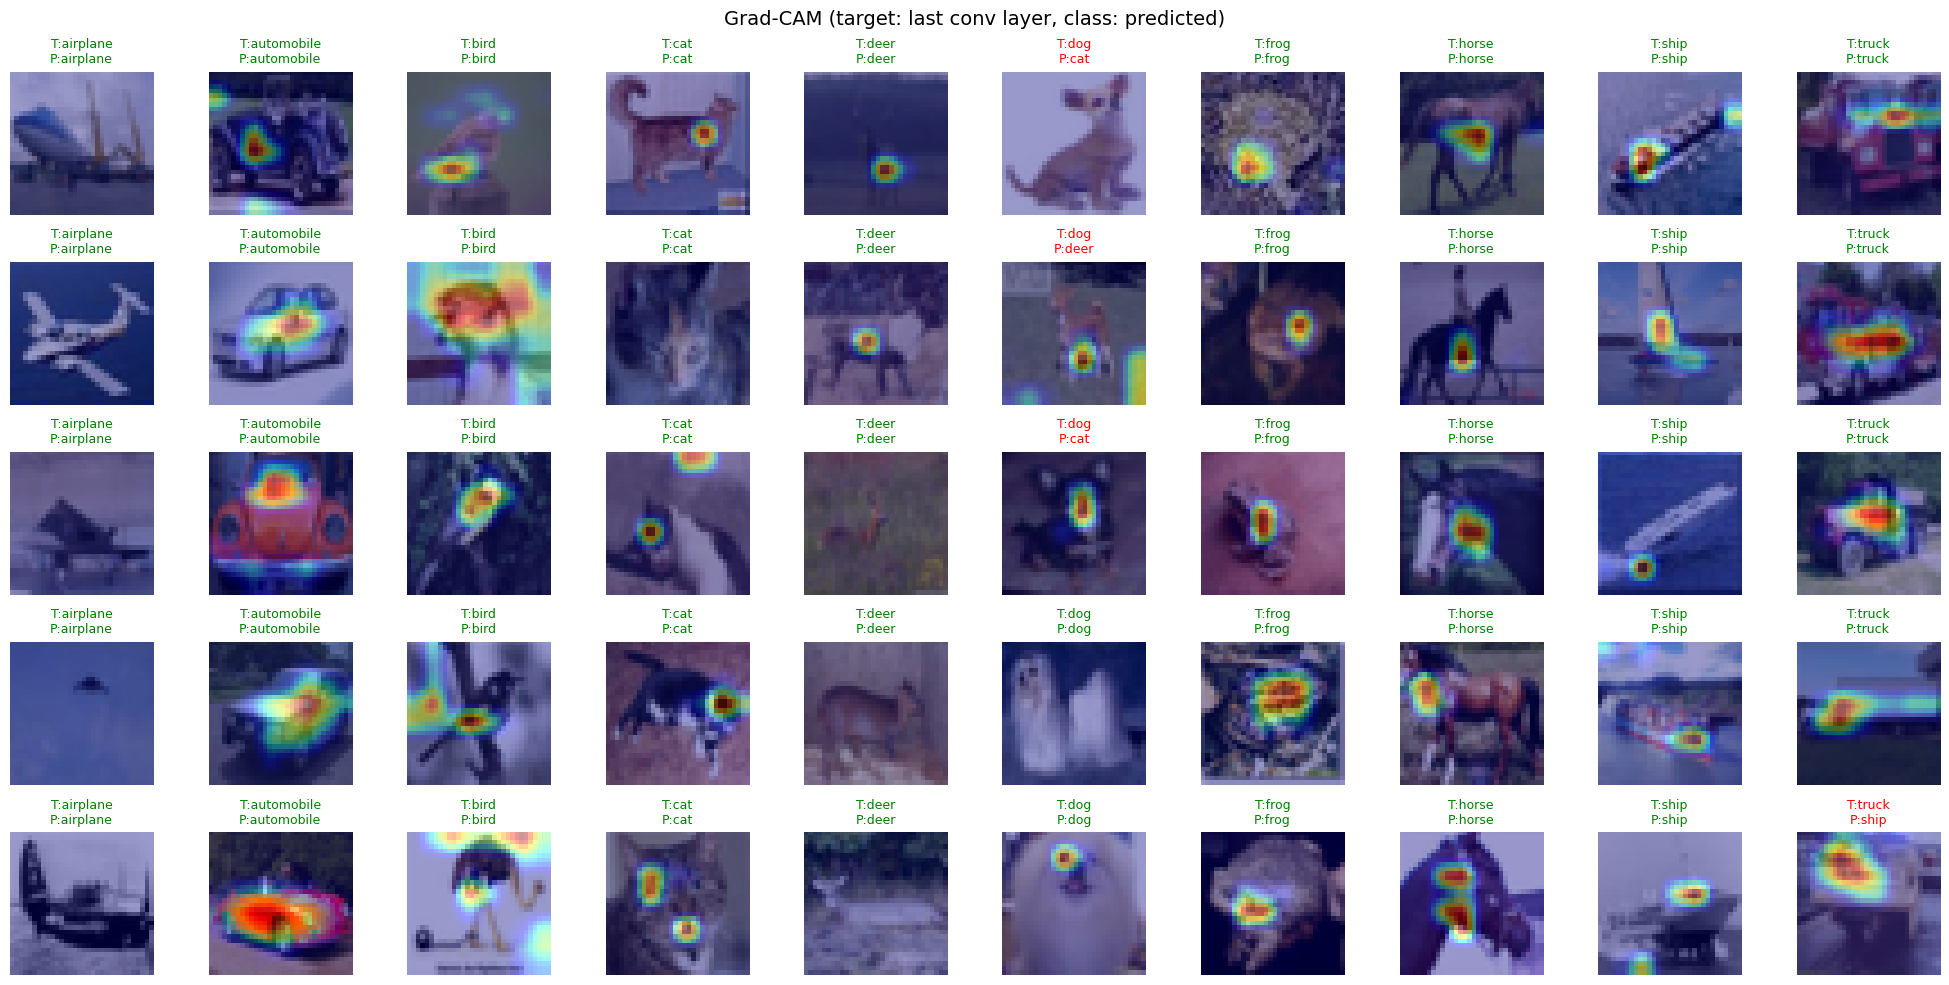

In [37]:
gradcam = GradCAM(model, target_layer)

fig, axes = plt.subplots(5, 10, figsize=(20, 10))
fig.suptitle("Grad-CAM (target: last conv layer, class: predicted)", fontsize=14)

for col in range(10):
    for row in range(5):
        idx = selected[col][row]

        img_vis, y_true = test_viz_dataset[idx]
        y_true = int(y_true)

        x_norm, _ = test_dataset[idx]
        x_norm = x_norm.unsqueeze(0).to(device)

        cam, y_pred = gradcam.generate(x_norm, class_idx=None)

        ax = axes[row, col]
        ax.imshow(img_vis.permute(1, 2, 0).numpy())
        ax.imshow(cam, cmap="jet", alpha=0.4)
        ax.axis("off")

        title = f"T:{classes[y_true]}\nP:{classes[y_pred]}"
        ax.set_title(title, fontsize=9, color=("red" if y_pred != y_true else "green"))

plt.tight_layout()
plt.show()

gradcam.close()

### ❓ Discussion 4: Trusting the Model

Examine the Grad-CAM heatmaps you generated.
1. **Focus Area:** Does the model look at the "right" part of the image? (e.g., For a 'dog' prediction, is the heatmap on the dog's face/body, or on the grass in the background?)
2. **Shortcuts:** Did you find any examples where the model looked at the wrong feature (e.g., using the sky to classify a plane) but still got the right answer? if so, provide an example with reference to the plotted image. This is often called "Shortcut Learning."
3. **Failure Cases:** For the *incorrectly* classified images, where was the model looking? Does the heatmap explain *why* it got confused?

<span style="color: teal; font-weight:bold;">

**YOUR ANSWER:**

1. yes in most cases, but for example not whole dog face but its attention is more on a little part of the face of the dog, or on eye of the dog, or on a part of the horse body

2. yes for example in the column 9, row 3 its looking to the water of the sea but it predicted right (😀 maybe it is smart and knowing from the water that its a ship)


3. yes for example in the column 6 row 2 its looking on the corner of the picture mostly that is it makes a mistake, but its not always for example in that same column row 3 its looking at the face of the dog but it made a mistake and classified it as a cat

</span>


## Exploring Convolutional layer Feature Maps

Visualize the first 8 feature maps of the first, middle, and final convolutional layers for 3 random samples, using the `jet` colormap and `upsampling` to match the size of the first layer. Display the original image alongside the feature maps for comparison.

In [38]:
model.eval()

first_conv  = model.block1[0]
middle_conv = model.block2[0]
final_conv  = model.block3[3]

layers = {
    "First conv (block1[0])": first_conv,
    "Middle conv (block2[0])": middle_conv,
    "Final conv (block3[3])": final_conv,
}

activations = {}
handles = []

def make_hook(name):
    def hook_fn(module, inp, out):
        activations[name] = out.detach().cpu()  # (B,C,H,W)
    return hook_fn
for name, layer in layers.items():
    handles.append(layer.register_forward_hook(make_hook(name)))

In [39]:
def norm_01(x):
    x = x.clone()
    x_min = x.min()
    x_max = x.max()
    return (x - x_min) / (x_max - x_min + 1e-8)

In [42]:
def plot_feature_maps_for_sample(sample_idx, num_maps=8):
    img_vis, y_true = test_viz_dataset[sample_idx]
    y_true = int(y_true)

    x_norm, _ = test_dataset[sample_idx]
    x_norm = x_norm.unsqueeze(0).to(device)

    activations.clear()

    with torch.no_grad():
        _ = model(x_norm)

    first_name = "First conv (block1[0])"
    H0, W0 = activations[first_name].shape[2], activations[first_name].shape[3]

    fig, axes = plt.subplots(3, 1 + num_maps, figsize=(2.2*(1+num_maps), 6.5))
    fig.suptitle(f"Sample idx {sample_idx} | True: {classes[y_true]}", fontsize=14)

    for r, (lname, _) in enumerate(layers.items()):
        feats = activations[lname]
        feats = feats[0]

        feats_up = F.interpolate(feats.unsqueeze(0), size=(H0, W0), mode="bilinear", align_corners=False)[0]

        ax0 = axes[r, 0]
        ax0.imshow(img_vis.permute(1, 2, 0).numpy())
        ax0.axis("off")
        ax0.set_title("Original", fontsize=10)

        for c in range(num_maps):
            fmap = norm_01(feats_up[c])
            ax = axes[r, 1 + c]
            ax.imshow(fmap.numpy(), cmap="jet")
            ax.axis("off")
            ax.set_title(f"{lname}\nMap {c}", fontsize=8)

    plt.tight_layout()
    plt.show()

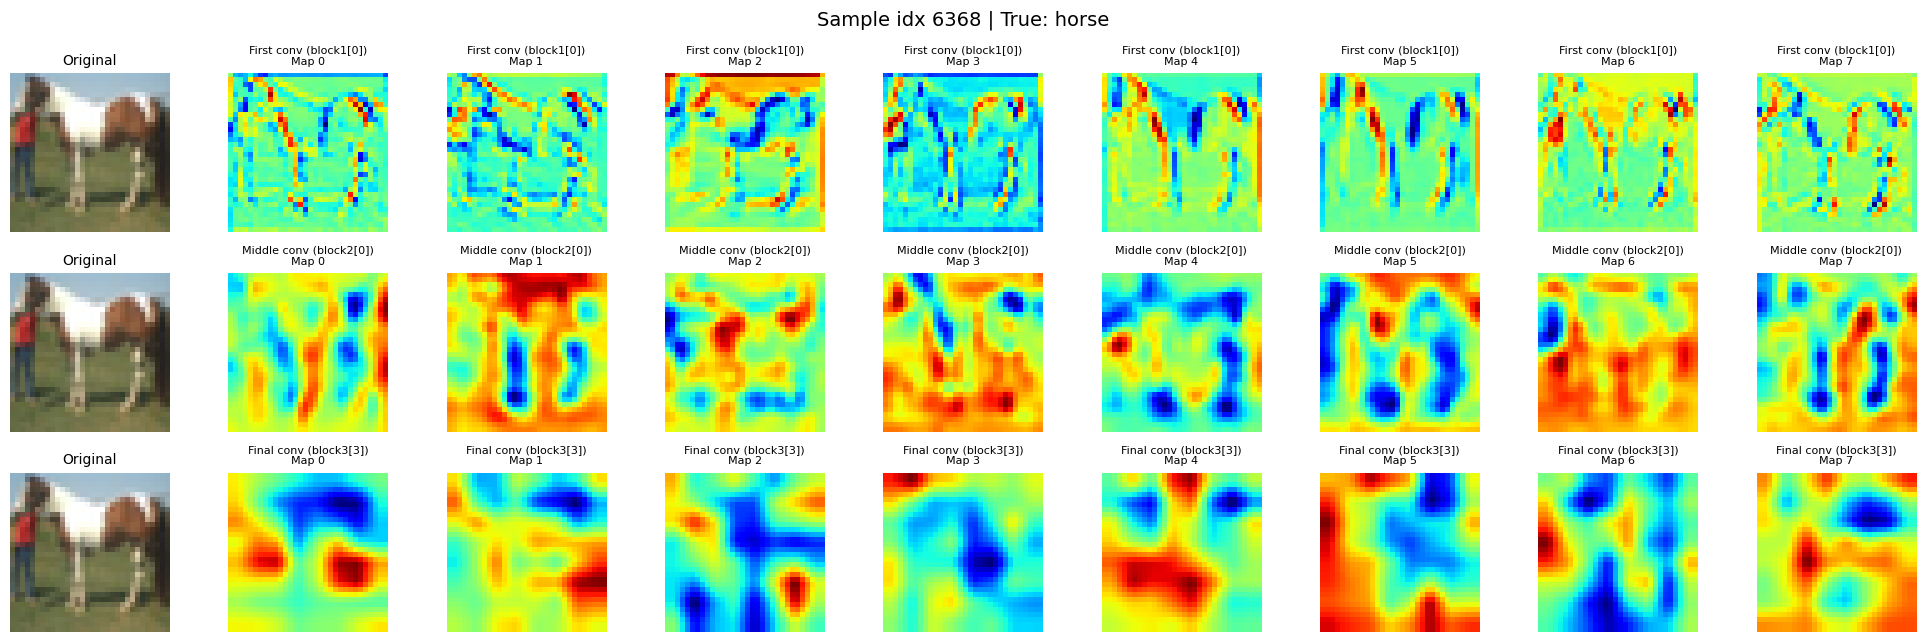

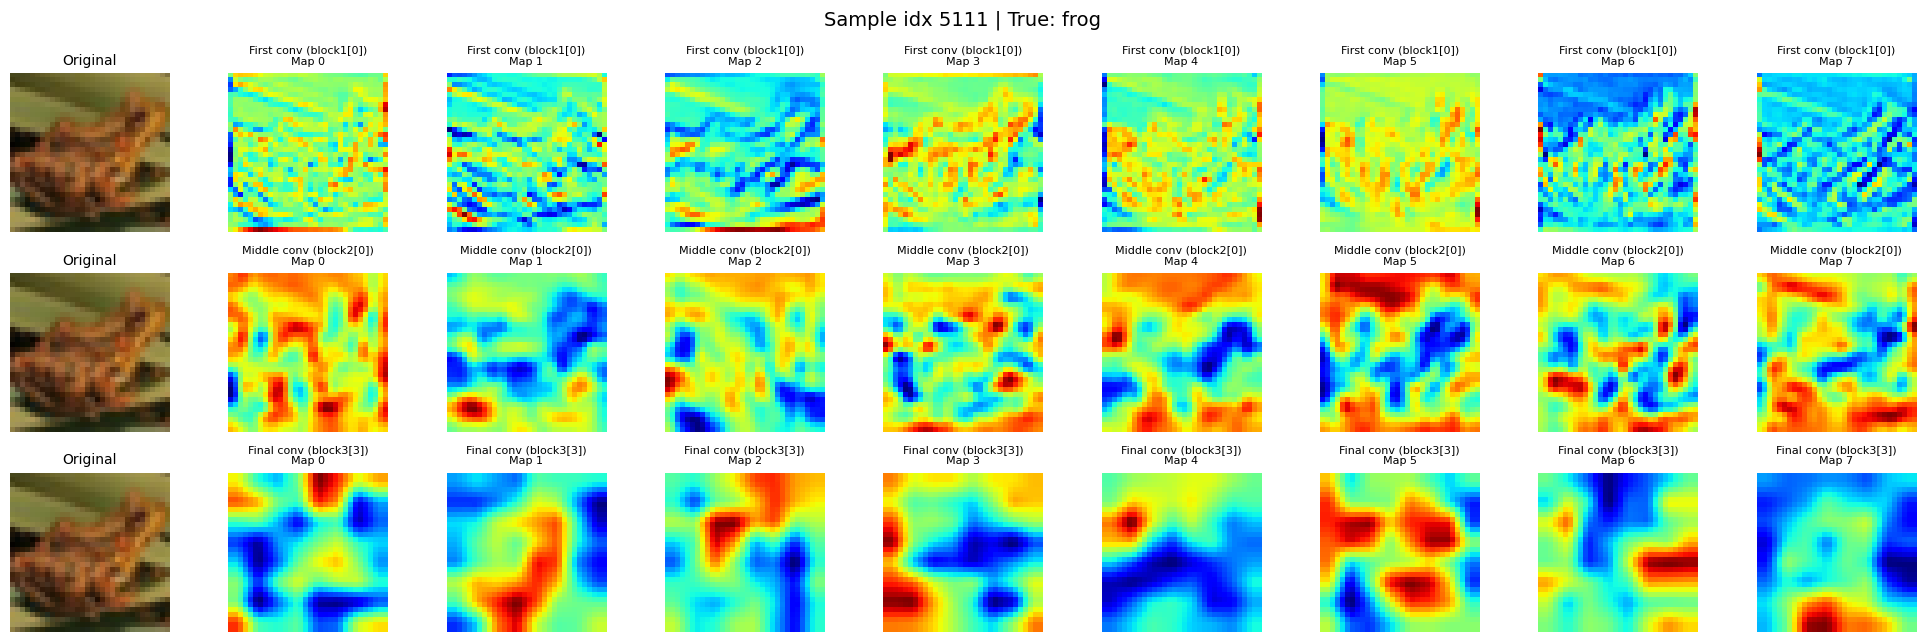

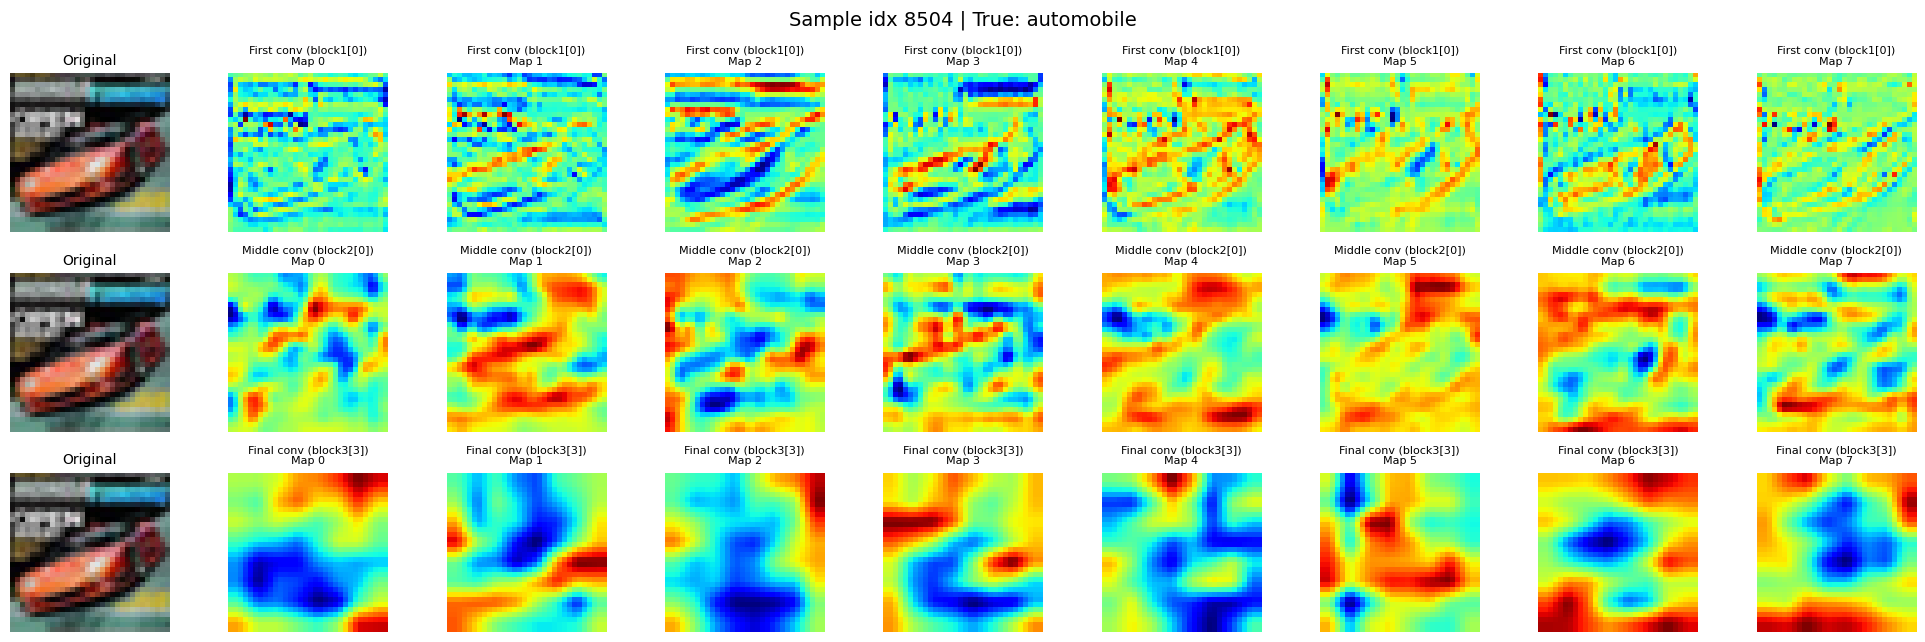

In [43]:
rng = np.random.default_rng(0)
sample_indices = rng.choice(len(test_dataset), size=3, replace=False)

for idx in sample_indices:
    plot_feature_maps_for_sample(int(idx), num_maps=8)

for h in handles:
    h.remove()

<span  style="color: teal; font-weight:bold;">

# As we go deeper the details gets more important 🚗
</span>